In [9]:
import os

# Set the PYTHONPATH
os.environ['PYTHONPATH'] = '/home/923714256/ML_denoising/raytune_lib'
print(os.environ['PYTHONPATH'])


import argparse
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib as mpl
import matplotlib.pyplot as plt

from raytune_CNN import DualBranchAutoencoder as CNNModel
from raytune_SingleCNN import SingleBranchAutoencoder as SingleBranchCNN # for the old model
from scipy.signal import hilbert
import raytune_training_function as tr_fu
from overleaf_plots import peak_time_analysis, peak_amplitude_analysis,  traces_plot, peak_amplitude_analysis_all_channels, traces_plot_v2, CustomDataset
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset, inset_axes
from DU_response_computation import apply_rfchain as rfc
import json


/home/923714256/ML_denoising/raytune_lib


### Multiloss

### Peak time Analysis CNN



In [10]:
import json
import os

# Path to your ray_results directory
ray_results_path = "/Users/923714256/ray_results/train_validate_wrapper_2025-07-16_14-15-35"

result_v2_path = '/Users/923714256/ML_denoising/raytune_lib/Result_v2/'

# Look for the best trial directory (trial 00024_24)
best_trial_dir = None
for item in os.listdir(ray_results_path):
    if "train_validate_wrapper_03ad7_00017_17" in item:
        best_trial_dir = os.path.join(ray_results_path, item)
        break

if best_trial_dir:
    # Read the params.json file
    params_file = os.path.join(best_trial_dir, "params.json")
    if os.path.exists(params_file):
        with open(params_file, 'r') as f:
            config = json.load(f)
        
        print("Model Configuration:")
        print(json.dumps(config['model_config'], indent=2))
save_folder_name = result_v2_path + '/multiloss_v2_CNN_20_100epochs_v2/results_dev_multiloss_v2_CNN_20_100epochs_v2_gauss_gal_100_multi_hdf5'
model_path = os.path.join(save_folder_name, 'best_model.pth')

CNN_model_config = {
    'time_branch': {'conv_channels': 64, 'res_channels': (128, 256)},
    'freq_branch': {'conv_channels': 64, 'res_channels': (32, 64)},
    'decoder_channels': [32,16,8,3]
}
CNNmodel = CNNModel(CNN_model_config)
device = torch.device('cpu')
state_dict = torch.load(model_path, map_location=device, weights_only=True)
CNNmodel.load_state_dict(state_dict)
CNNmodel.to(device)
CNNmodel.eval()

## Load Jason File
json_params_file = '/Users/923714256/ML_denoising/raytune_lib/params_files/raytune_denoising_v1.json'
with open(json_params_file, 'r') as f:
        all_params = json.load(f)
tag = all_params['tag']
which_noise = all_params['which_noise']
lst = all_params['lst']
model_to_load = all_params['model_to_load']
xy_mode = all_params['xy_mode']
noise_param_file = all_params['noise_param_file']

## Define the noise and rf chain.
with open(noise_param_file, 'r') as f:
        params_RF2 = json.load(f)

### loading RF and noise params
a2 = rfc.load_parameters_and_compute_stuff(params_RF2)
l_eff2 = a2[0]
tf2 = a2[1]
latitude2 = a2[2]
out_freqs2 = a2[3]
LFmap_path = params_RF2['LFmap_path']

noise_computer2 = rfc.compute_noise(1, latitude2,
                                [f"{LFmap_path}LFmapshort{i}.npy" for i in range(20, 251)],
                                np.arange(20, 251)*1e6,
                                out_freqs2,
                                tf2,
                                duration=params_RF2['duration'], leff_x=l_eff2[0], leff_y=l_eff2[1], leff_z=l_eff2[2])
noise_computer2.P_nu
noise_computer2.noise_rms_traces()

real_an_test_file = all_params["real_an_test_file"]
save_path_clean_sims_test = all_params["save_path_clean_sims_test"]
clean_signals_test = np.load(save_path_clean_sims_test).transpose(1, 0, 2)

test_dataset = tr_fu.CustomDataset_hdf5(clean_signals_test, noise_computer2, no_random=False, lst=lst, xy_mode=xy_mode, which_noise=which_noise, real_an_noisefile=real_an_test_file)
test_loader = DataLoader(test_dataset, batch_size=1, num_workers=4, shuffle=False, pin_memory=True)


Model Configuration:
{
  "decoder_channels": [
    32,
    16,
    8,
    3
  ],
  "freq_branch": {
    "conv_channels": 64,
    "res_channels": [
      32,
      64
    ]
  },
  "time_branch": {
    "conv_channels": 64,
    "res_channels": [
      128,
      256
    ]
  }
}
Calculating noise power for LST 0.00 hours
(231, 72, 36)
(231, 72, 36)
(231, 72, 36)
Calculating noise power for LST 1.00 hours
(231, 72, 36)
(231, 72, 36)
(231, 72, 36)
Calculating noise power for LST 2.00 hours
(231, 72, 36)
(231, 72, 36)
(231, 72, 36)
Calculating noise power for LST 3.00 hours
(231, 72, 36)
(231, 72, 36)
(231, 72, 36)
Calculating noise power for LST 4.00 hours
(231, 72, 36)
(231, 72, 36)
(231, 72, 36)
Calculating noise power for LST 5.00 hours
(231, 72, 36)
(231, 72, 36)
(231, 72, 36)
Calculating noise power for LST 6.00 hours
(231, 72, 36)
(231, 72, 36)
(231, 72, 36)
Calculating noise power for LST 7.00 hours
(231, 72, 36)
(231, 72, 36)
(231, 72, 36)
Calculating noise power for LST 8.00 hours
(

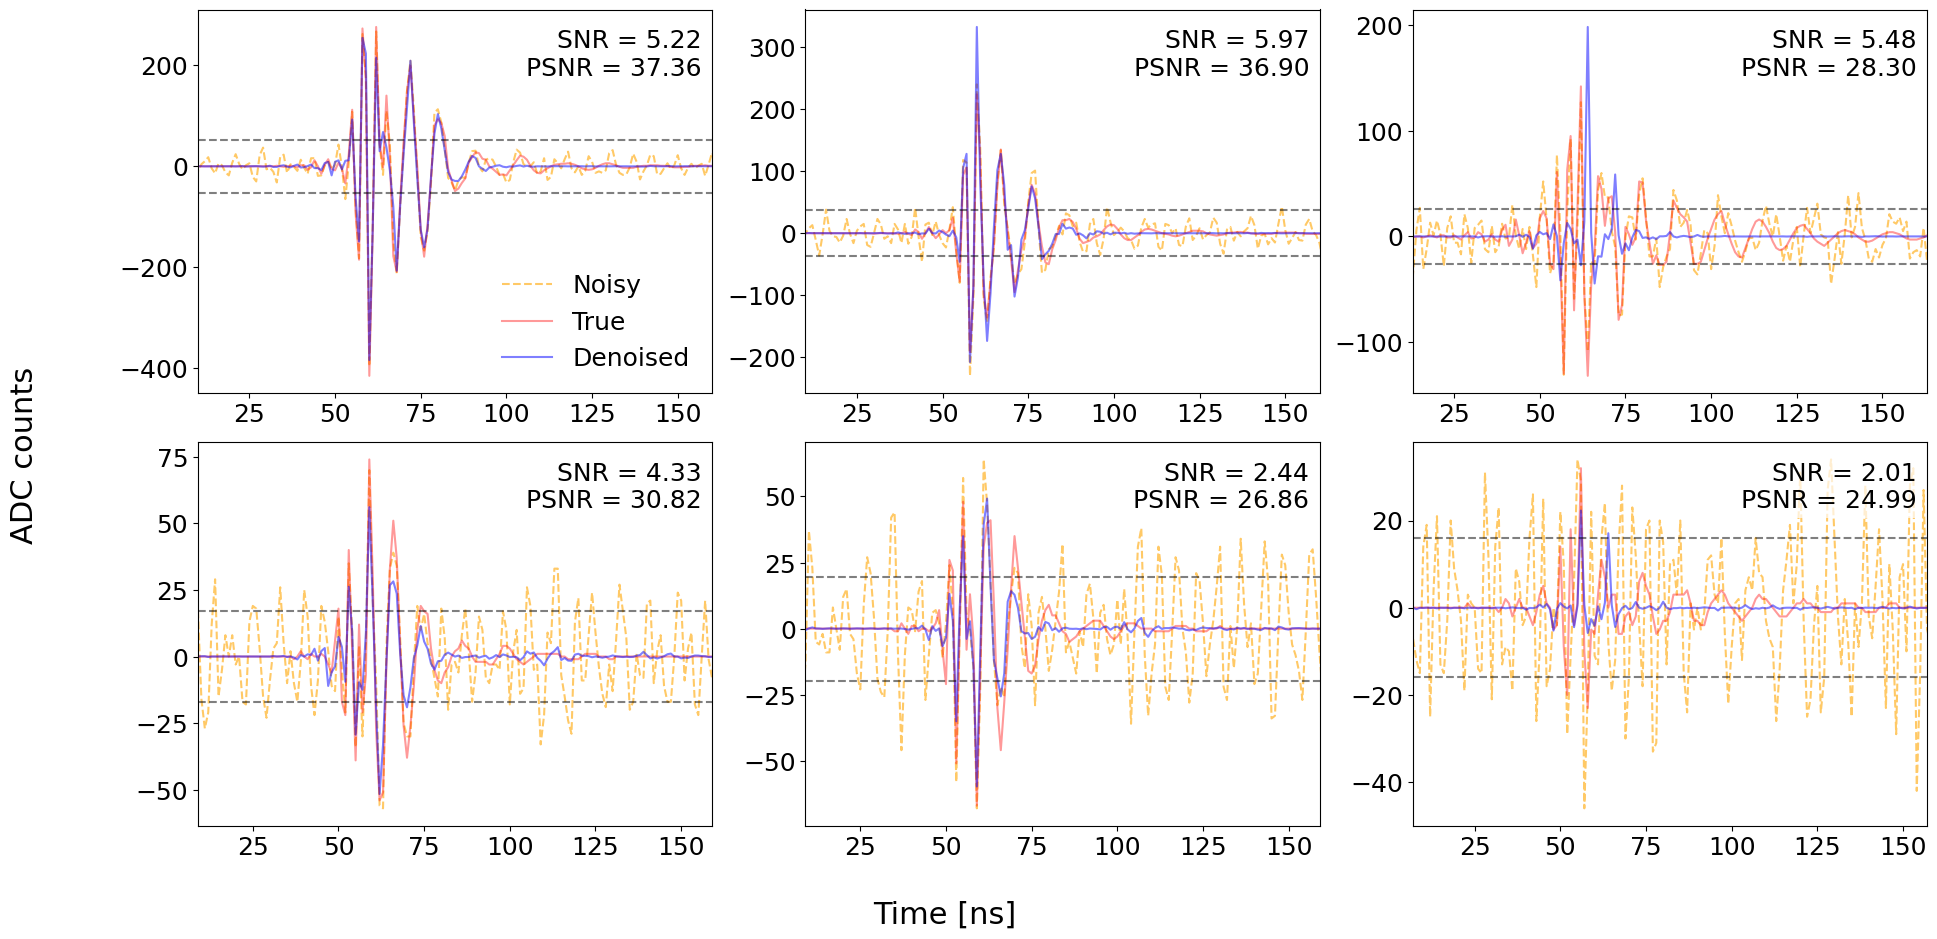

traces_plot_v2 completed


In [11]:
# test(testloader = test_loader, 
#          model = CNNmodel, 
#          num_images = 12, 
#          device="cpu", 
#          min_snr = 1, 
#          max_snr = 1e3)

traces_plot_v2(testloader = test_loader, 
            model = CNNmodel, 
            num_images = 12, 
            device="cpu",
            save_path = '')#/Users/923714256/ML_denoising/raytune_lib


### Peak Time Analysis

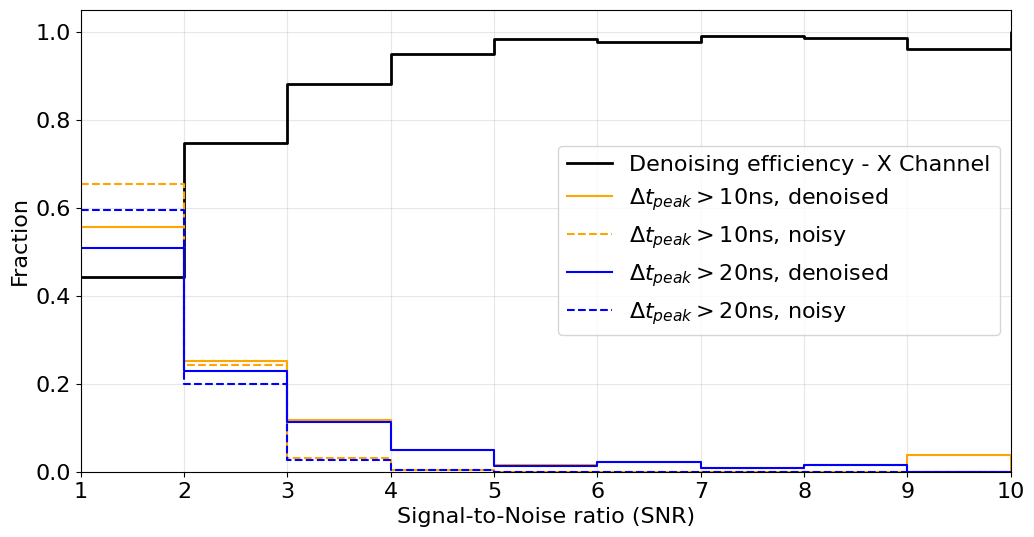

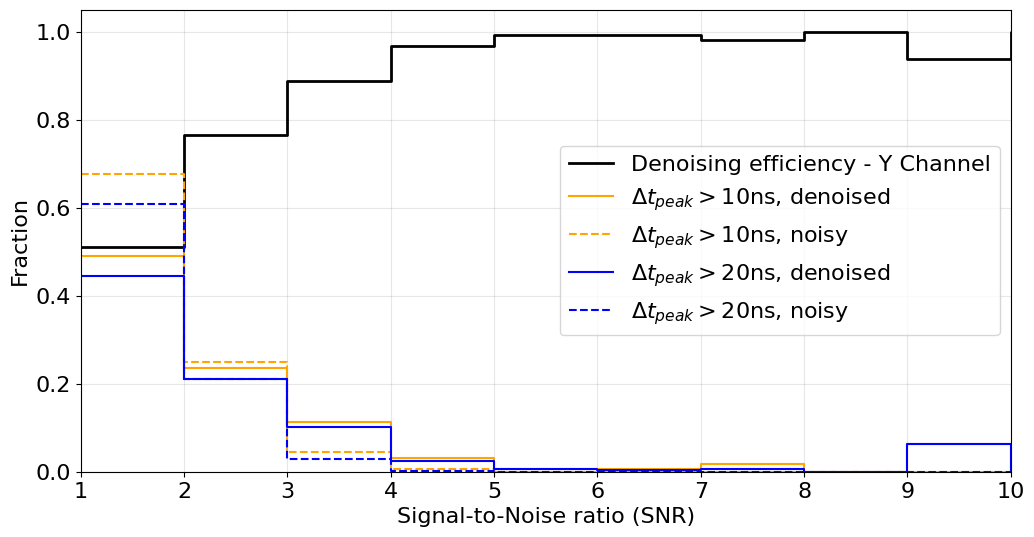

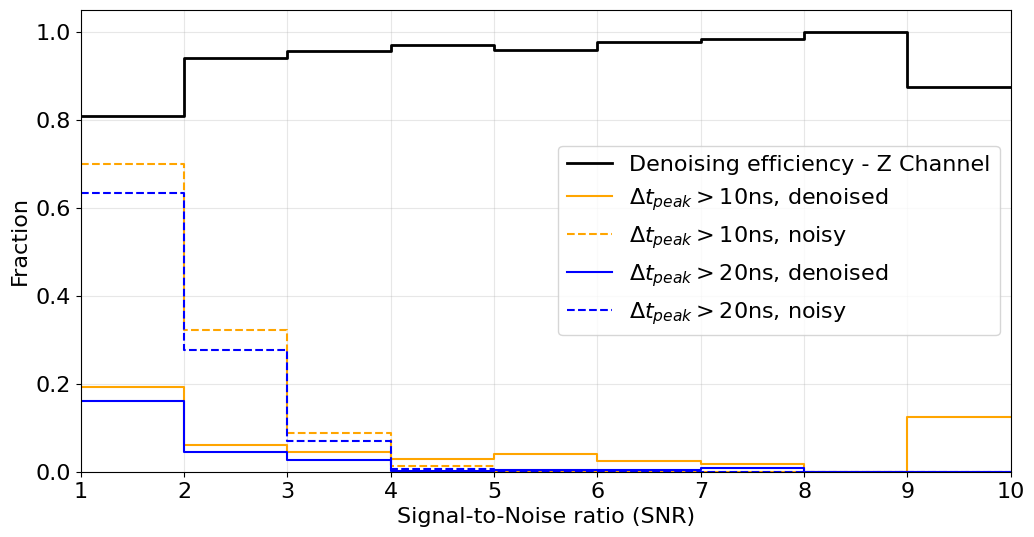

In [12]:
peak_time_analysis(dataloader = test_loader, 
                   model = CNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=1, 
                   max_snr=1e3)

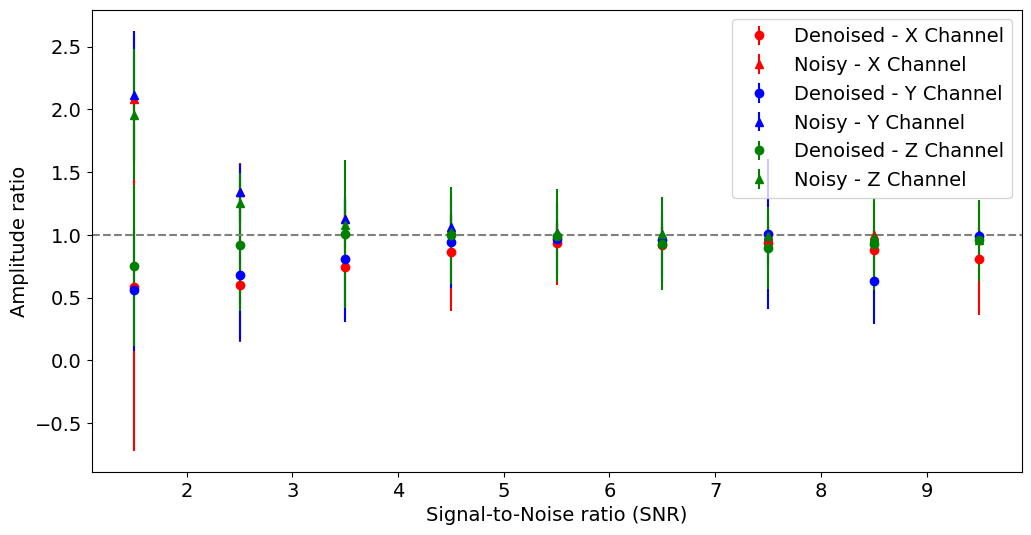

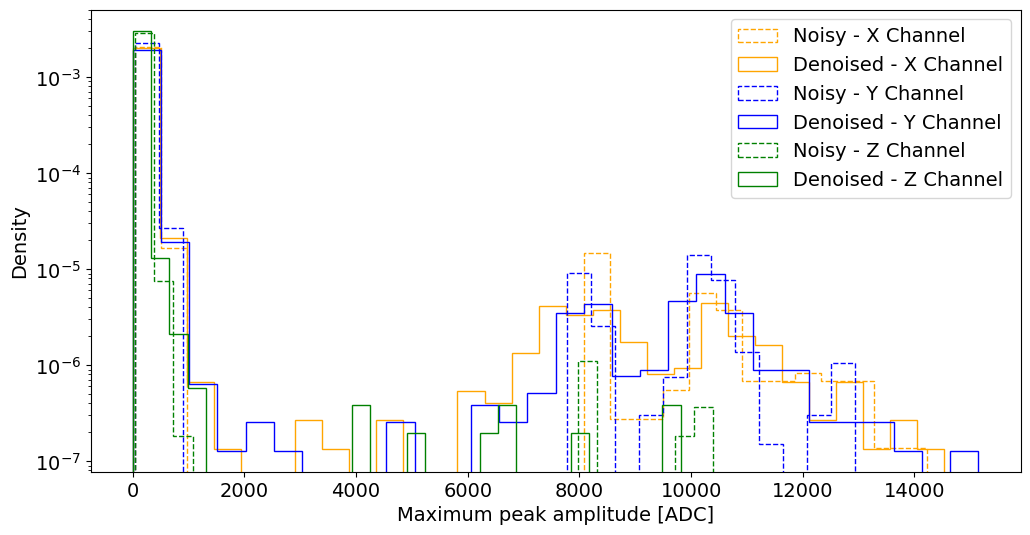

In [13]:
peak_amplitude_analysis_all_channels(dataloader = test_loader, 
                   model = CNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=0, 
                   max_snr=1e3)

Model Configuration:
{
  "decoder_channels": [
    64,
    32,
    16,
    3
  ],
  "time_branch": {
    "conv_channels": 16,
    "res_channels": [
      128,
      256
    ]
  }
}


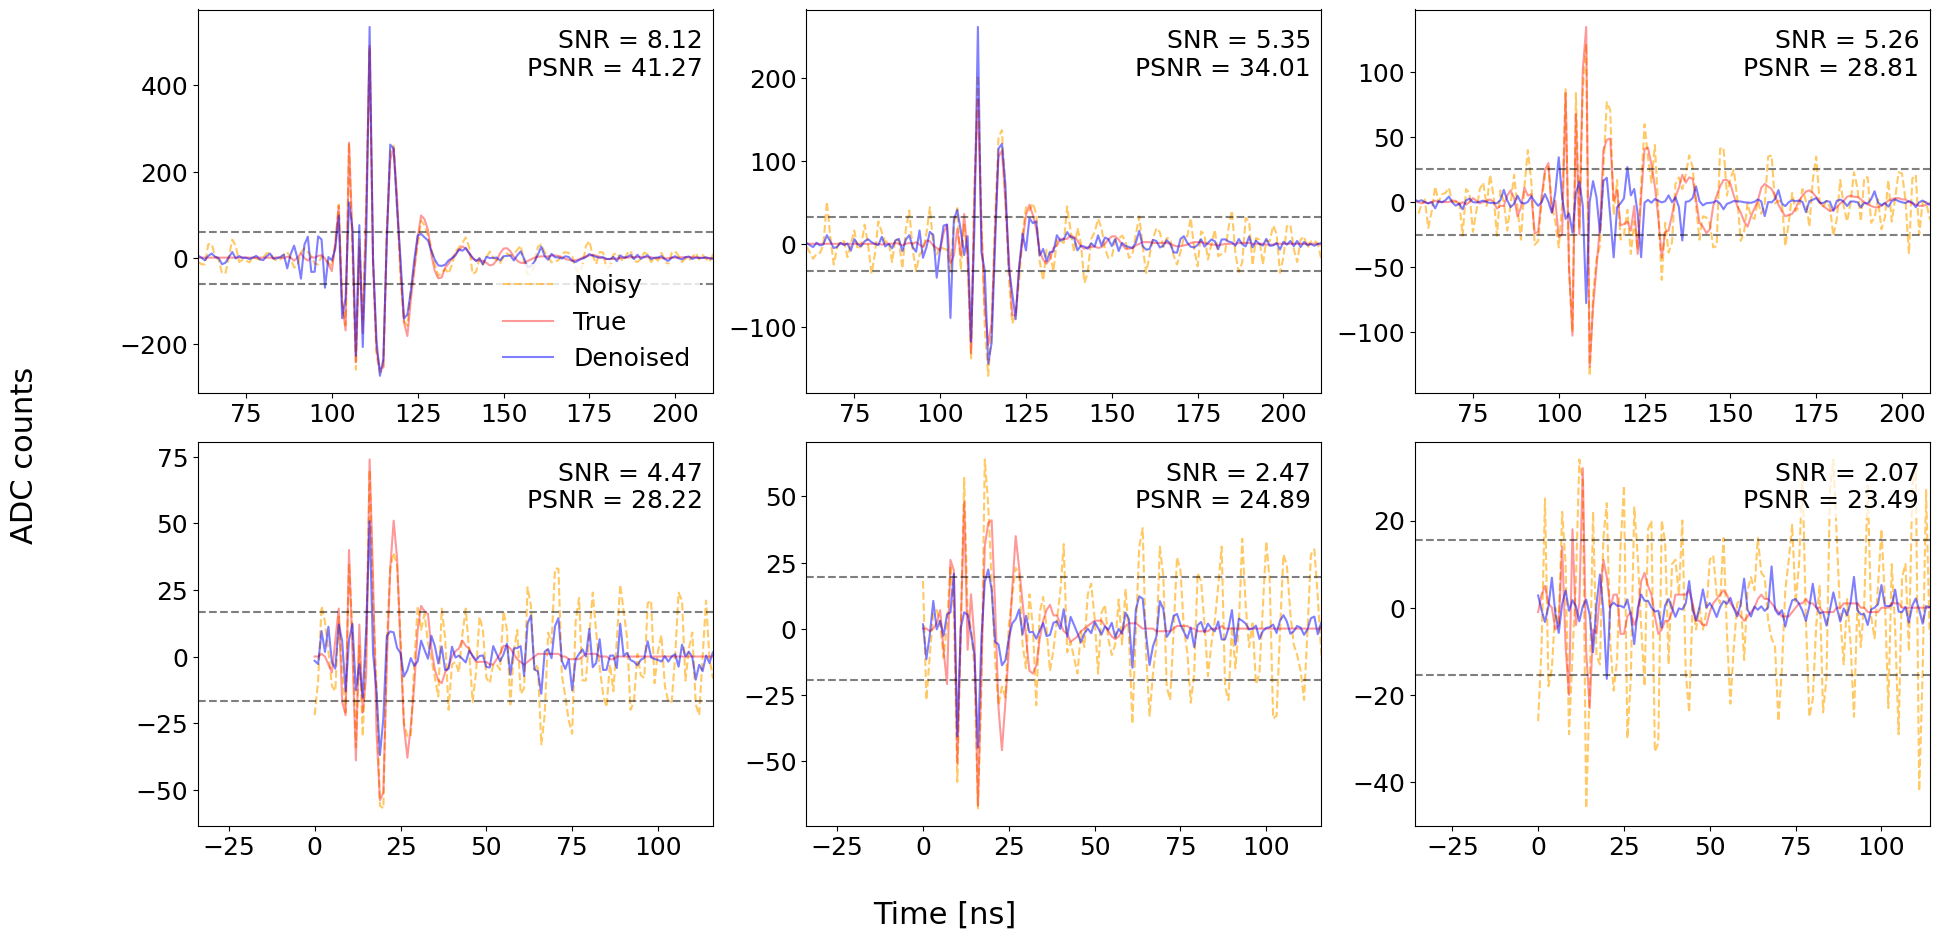

traces_plot_v2 completed


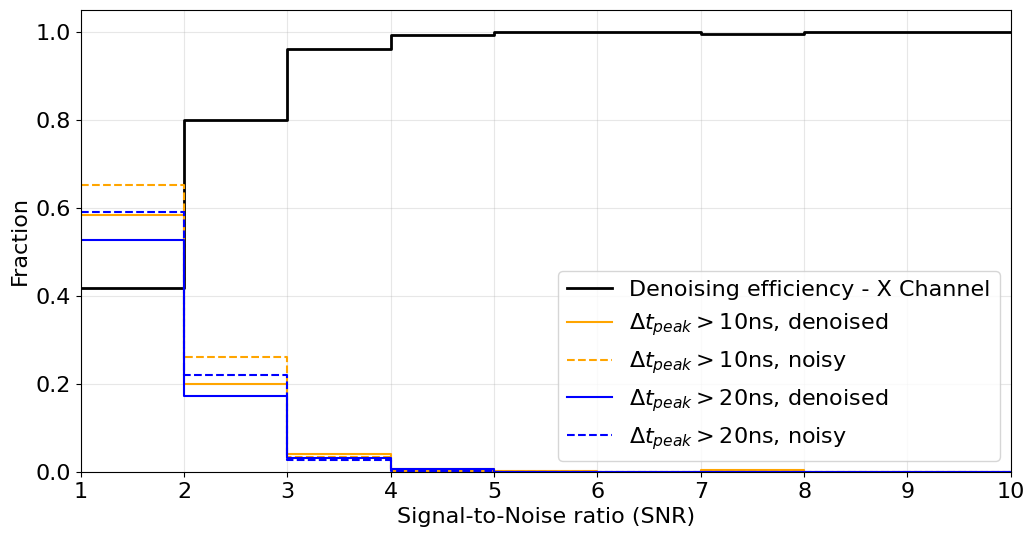

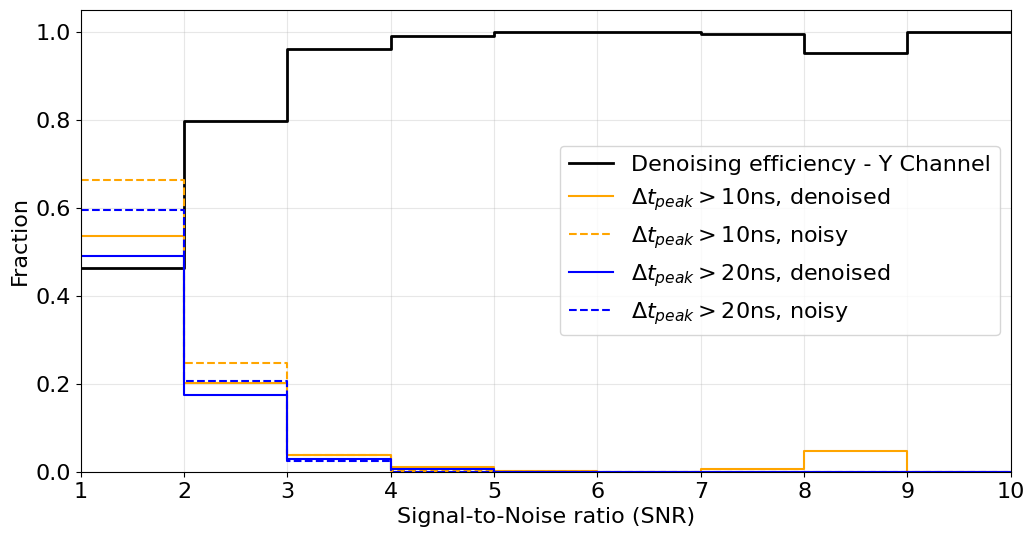

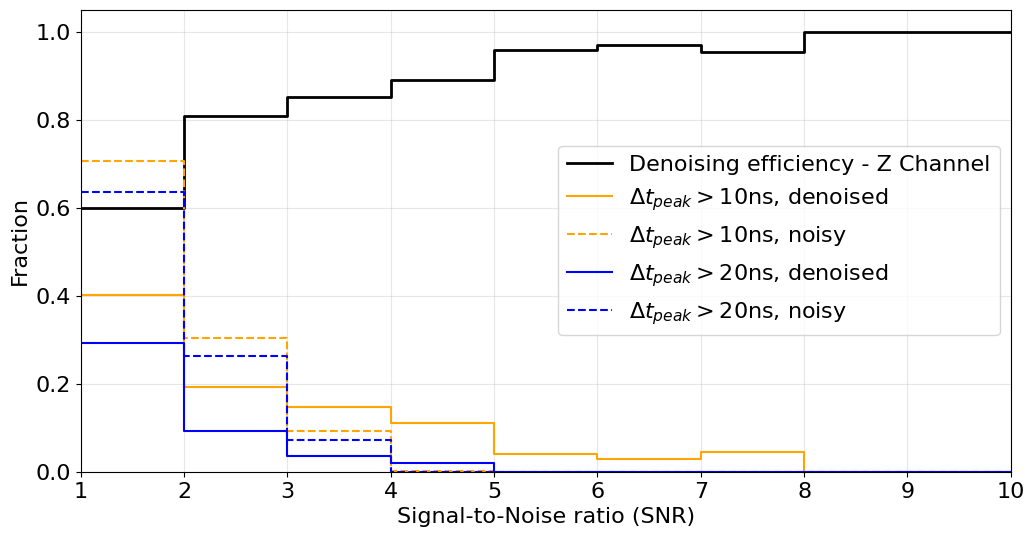

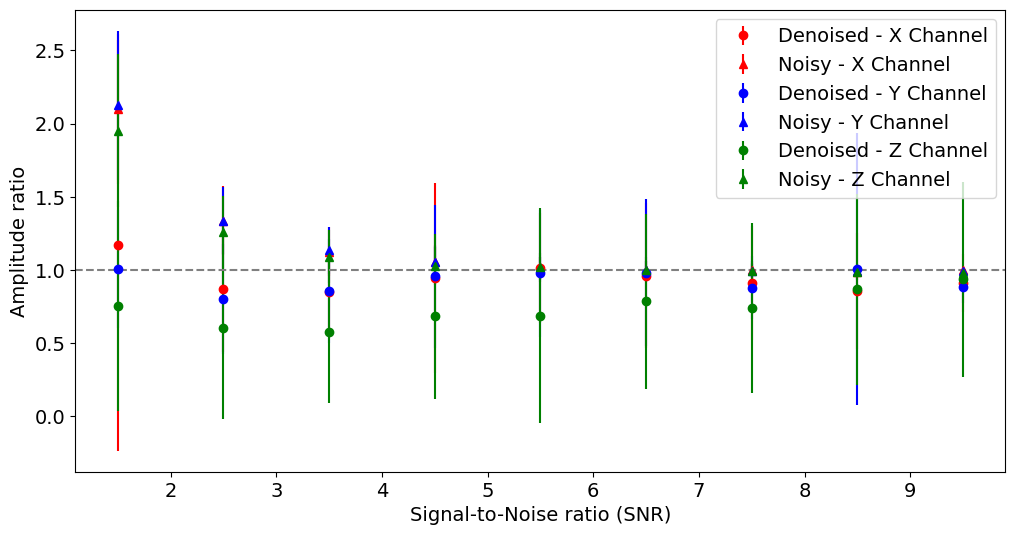

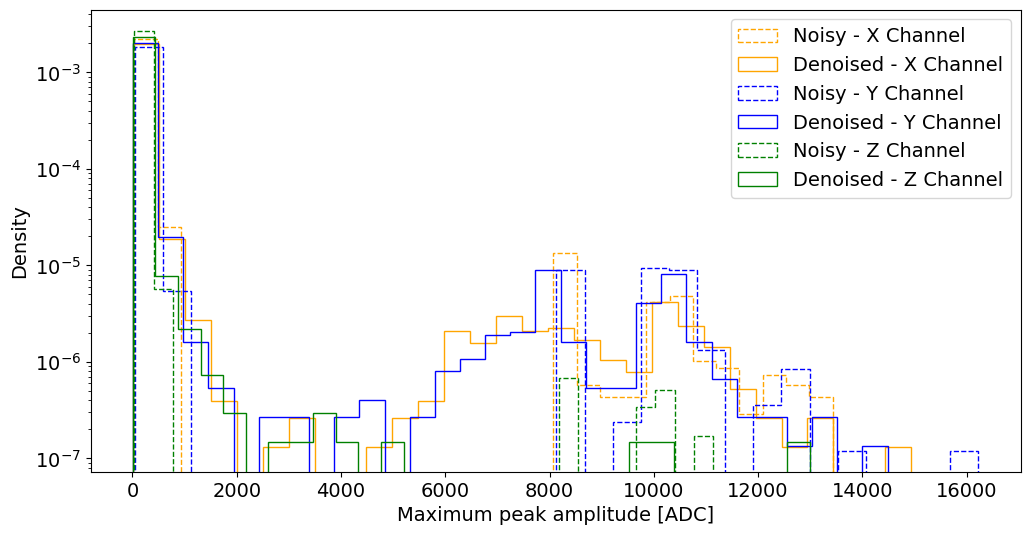

In [14]:
import json
import os

# Path to your ray_results directory
ray_results_path = "/Users/923714256/ray_results/train_validate_wrapper_2025-07-16_23-28-17"

# Look for the best trial directory (trial 00024_24)
best_trial_dir = None
for item in os.listdir(ray_results_path):
    if "train_validate_wrapper_3990e_00006_6" in item:
        best_trial_dir = os.path.join(ray_results_path, item)
        break

if best_trial_dir:
    # Read the params.json file
    params_file = os.path.join(best_trial_dir, "params.json")
    if os.path.exists(params_file):
        with open(params_file, 'r') as f:
            config = json.load(f)
        
        print("Model Configuration:")
        print(json.dumps(config['model_config'], indent=2))
save_folder_name = result_v2_path + 'multiloss_v2_SINGCNN_20_100epochs_v2/results_dev_multiloss_v2_SINGCNN_20_100epochs_v2_gauss_gal_100_multi_hdf5'
model_path = os.path.join(save_folder_name, 'best_model.pth')
SingleBranchCNN_model_config={
  "decoder_channels": [
    64,
    32,
    16,
    3
  ],
  "time_branch": {
    "conv_channels": 16,
    "res_channels": [
      128,
      256
    ]
  }
}
SingleBranchCNNmodel = SingleBranchCNN(SingleBranchCNN_model_config)
device = torch.device('cpu')
SingleBranchCNNmodel.to(device)
state_dict = torch.load(model_path, map_location=device, weights_only=True)
SingleBranchCNNmodel.load_state_dict(state_dict)
SingleBranchCNNmodel.to(device)
SingleBranchCNNmodel.eval()

traces_plot_v2(testloader = test_loader, 
            model = SingleBranchCNNmodel, 
            num_images = 12, 
            device="cpu",
            save_path = '')

peak_time_analysis(dataloader = test_loader, 
                   model = SingleBranchCNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=1, 
                   max_snr=1e3)

peak_amplitude_analysis_all_channels(dataloader = test_loader, 
                   model = SingleBranchCNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=0, 
                   max_snr=1e3)

### MSE 

### CNN


Model Configuration:
{
  "decoder_channels": [
    128,
    64,
    32,
    3
  ],
  "freq_branch": {
    "conv_channels": 32,
    "res_channels": [
      128,
      256
    ]
  },
  "time_branch": {
    "conv_channels": 16,
    "res_channels": [
      128,
      256
    ]
  }
}


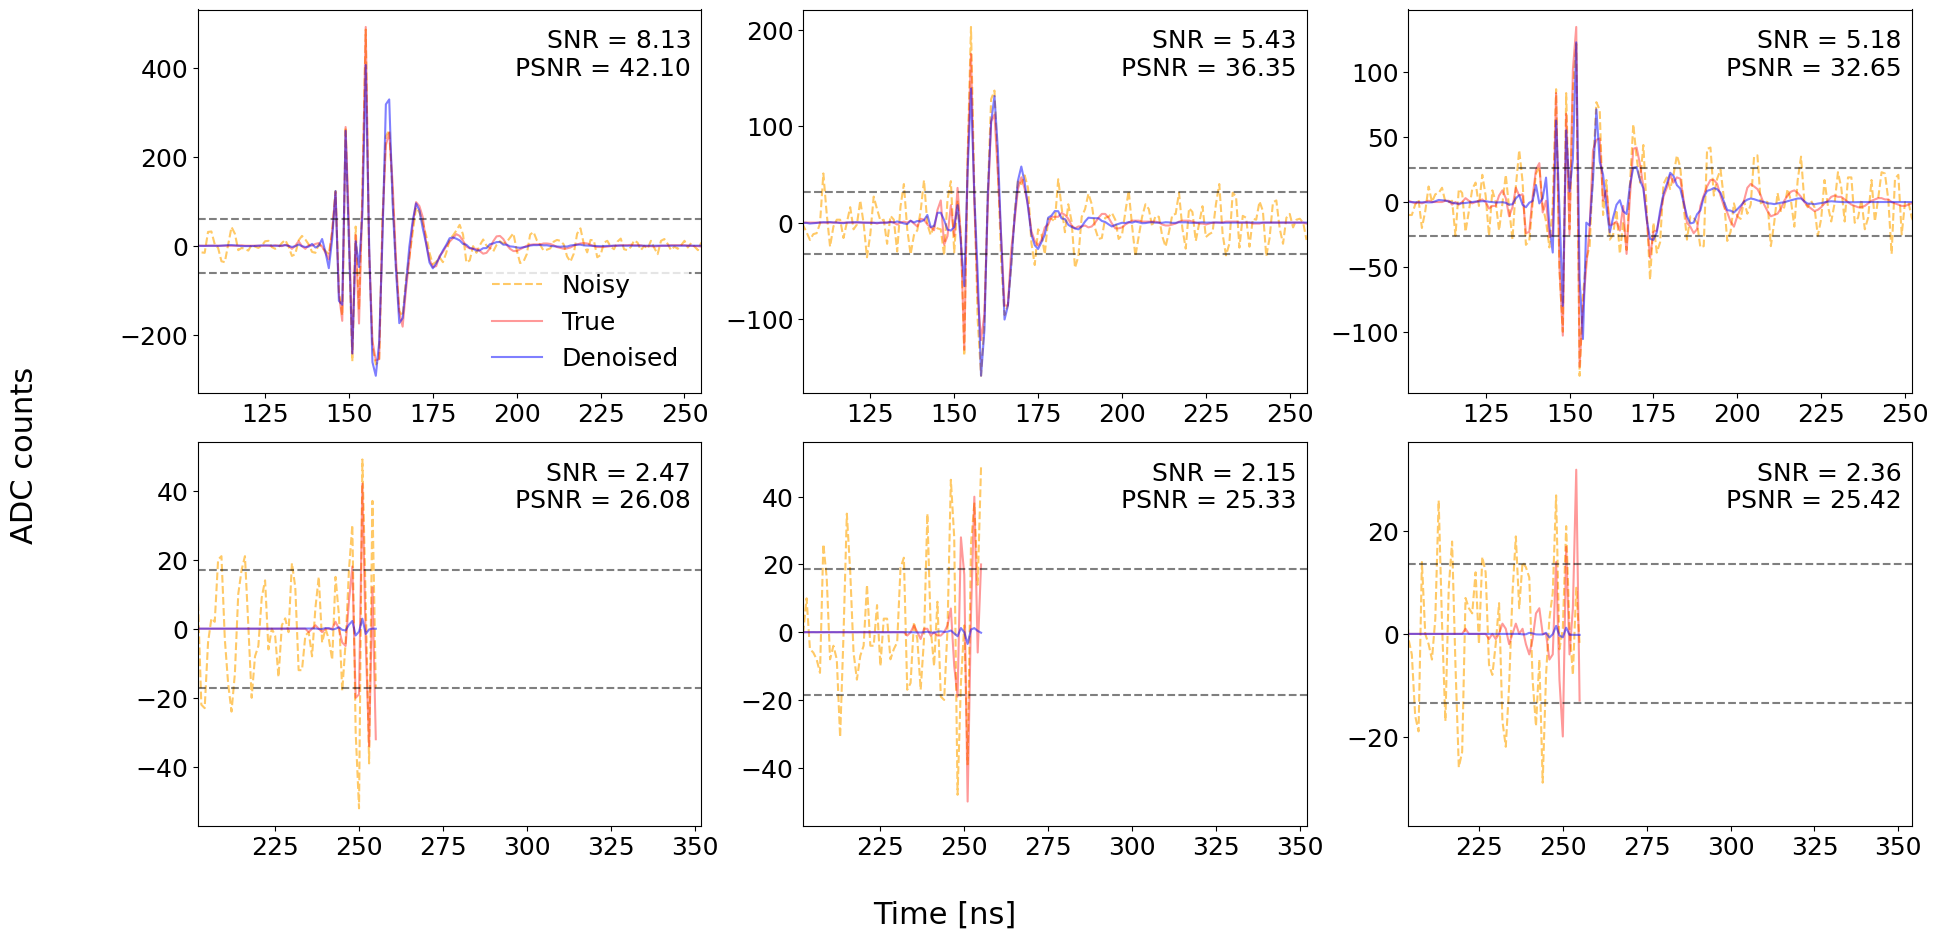

traces_plot_v2 completed


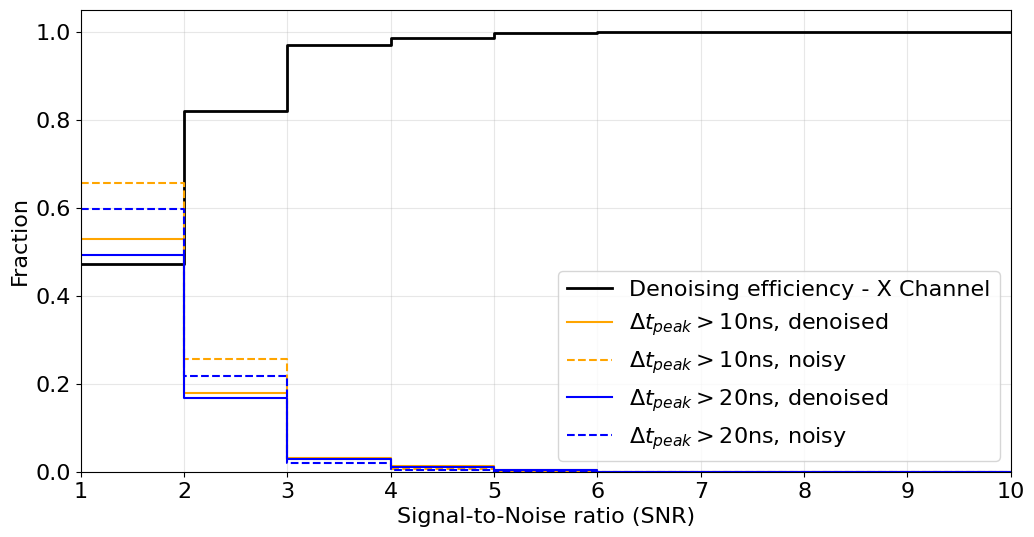

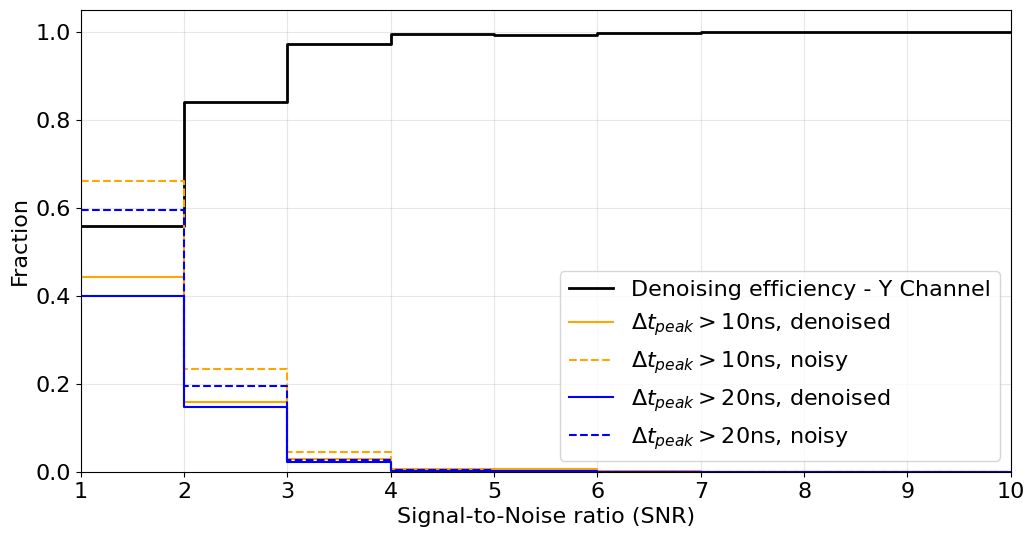

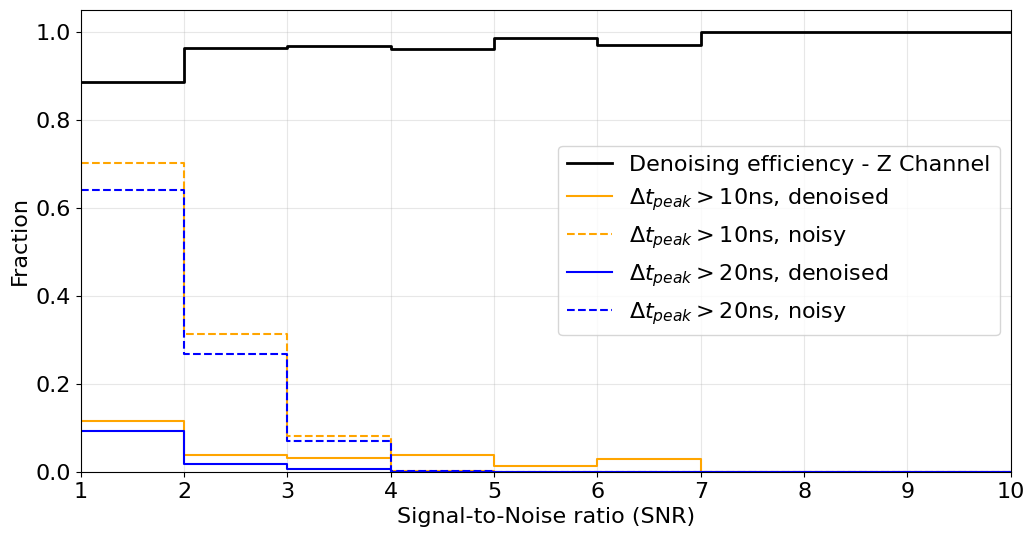

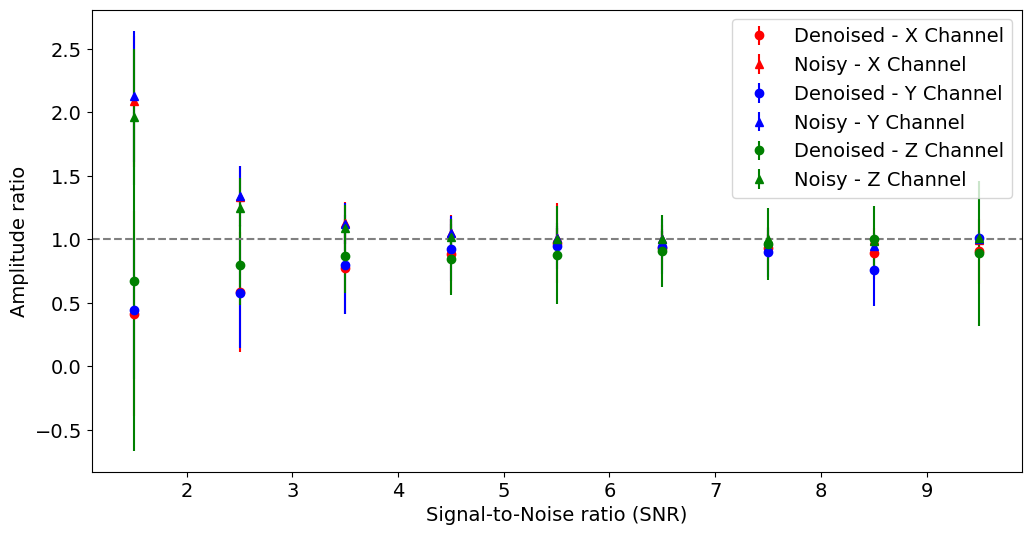

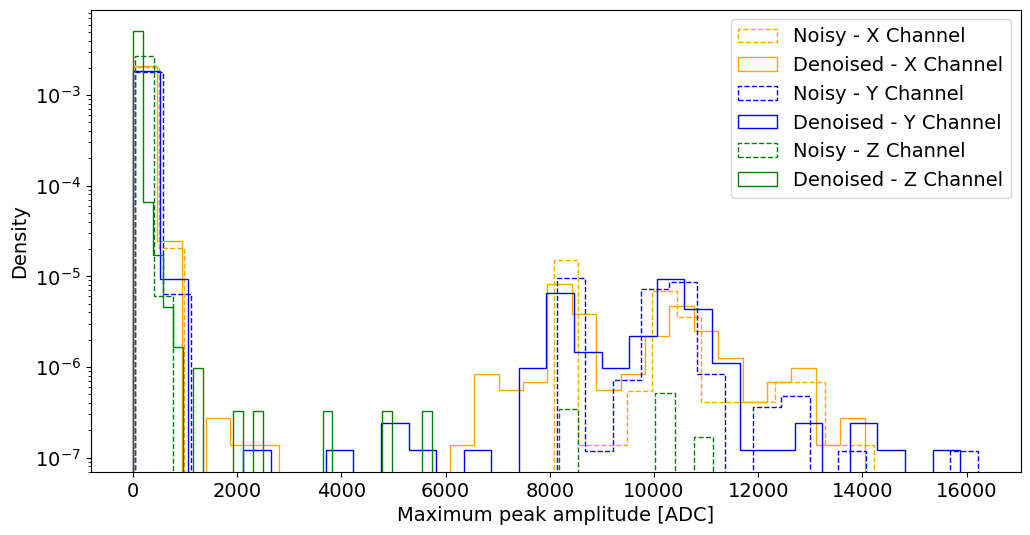

In [15]:
# Path to your ray_results directory
ray_results_path = "/Users/923714256/ray_results/train_validate_wrapper_2025-07-16_23-35-36"

# Look for the best trial directory (trial 00024_24)
best_trial_dir = None
for item in os.listdir(ray_results_path):
    if "train_validate_wrapper_3f6b1_00000_0" in item:
        best_trial_dir = os.path.join(ray_results_path, item)
        break

if best_trial_dir:
    # Read the params.json file
    params_file = os.path.join(best_trial_dir, "params.json")
    if os.path.exists(params_file):
        with open(params_file, 'r') as f:
            config = json.load(f)
        
        print("Model Configuration:")
        print(json.dumps(config['model_config'], indent=2))
save_folder_name = result_v2_path + 'mse_v2_CNN_20_100epochs_v2/results_dev_mse_v2_CNN_20_100epochs_v2_gauss_gal_100_mse_hdf5'
model_path = os.path.join(save_folder_name, 'best_model.pth')

CNN_model_config = {
    'time_branch': {'conv_channels': 16, 'res_channels': (128, 256)},
    'freq_branch': {'conv_channels': 32, 'res_channels': (128, 256)},
    'decoder_channels': [128,64,32,3]
}
CNNmodel = CNNModel(CNN_model_config)
device = torch.device('cpu')
state_dict = torch.load(model_path, map_location=device, weights_only=True)
CNNmodel.load_state_dict(state_dict)
CNNmodel.to(device)
CNNmodel.eval()

traces_plot_v2(testloader = test_loader, 
            model = CNNmodel, 
            num_images = 12, 
            device="cpu",
            save_path = '')


peak_time_analysis(dataloader = test_loader, 
                   model = CNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=1, 
                   max_snr=1e3)


peak_amplitude_analysis_all_channels(dataloader = test_loader, 
                   model = CNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=0, 
                   max_snr=1e3)


### SINGCNN

Model Configuration:
{
  "decoder_channels": [
    32,
    16,
    8,
    3
  ],
  "time_branch": {
    "conv_channels": 16,
    "res_channels": [
      128,
      256
    ]
  }
}


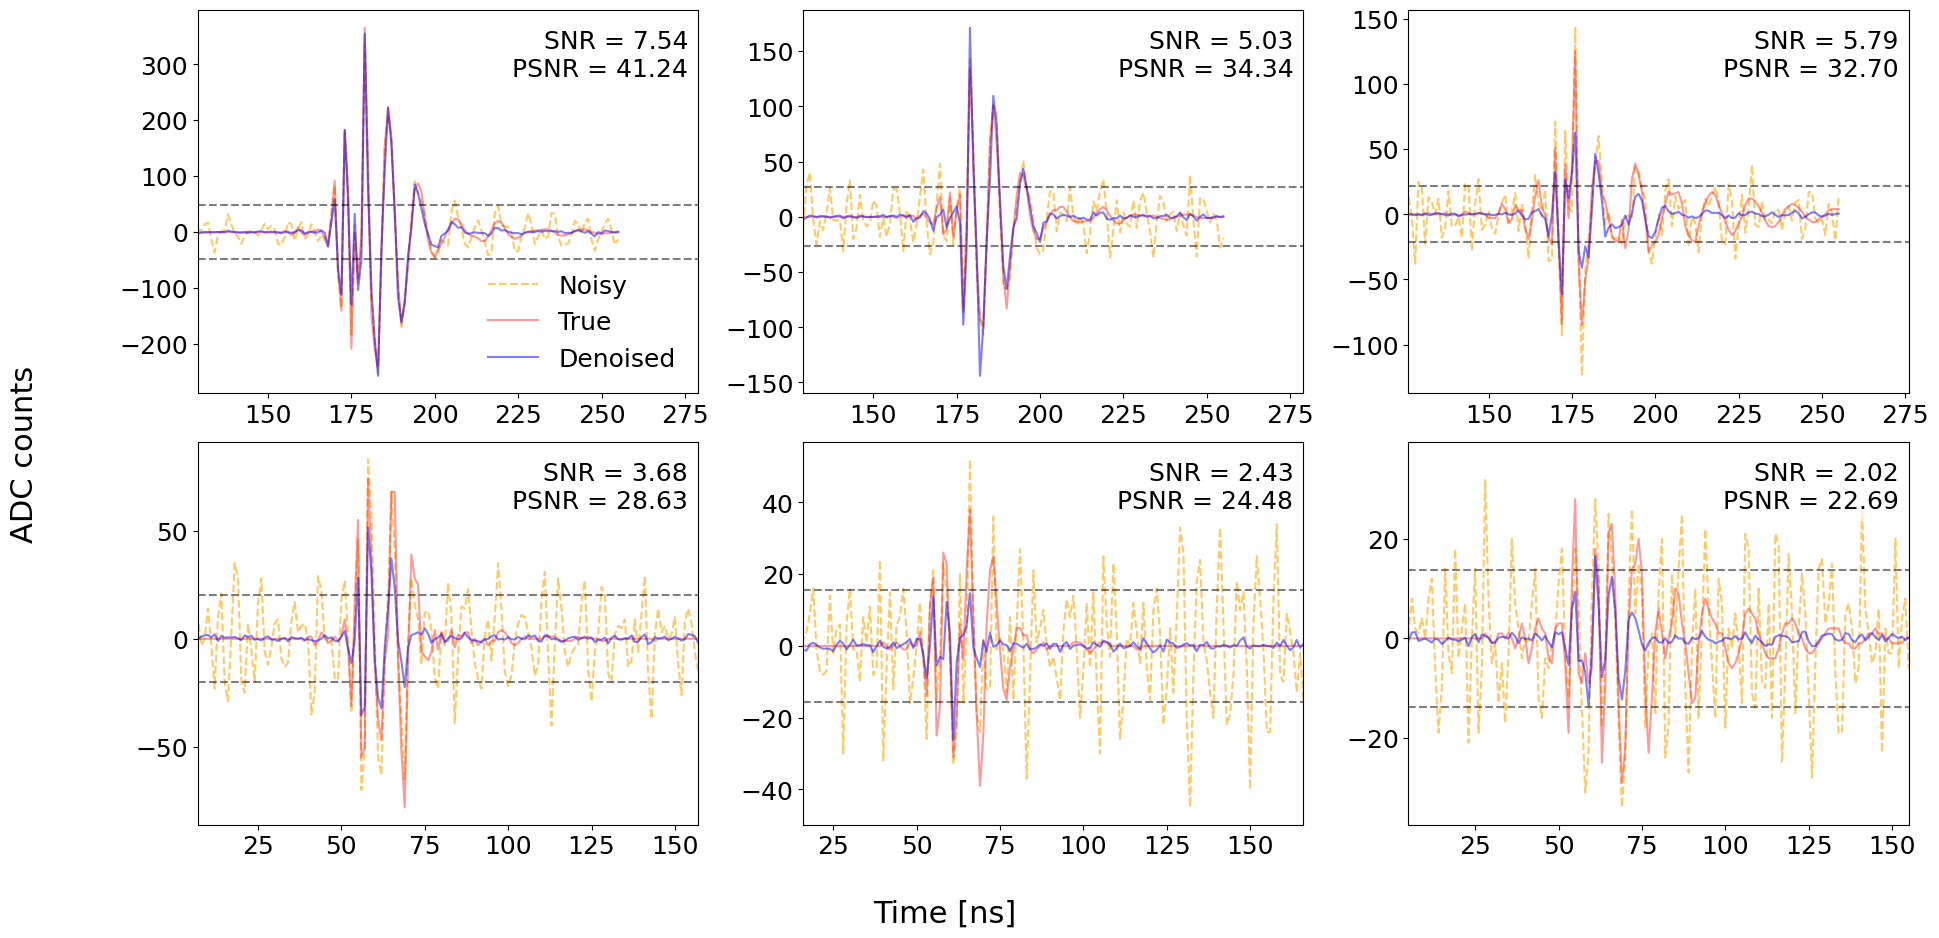

traces_plot_v2 completed


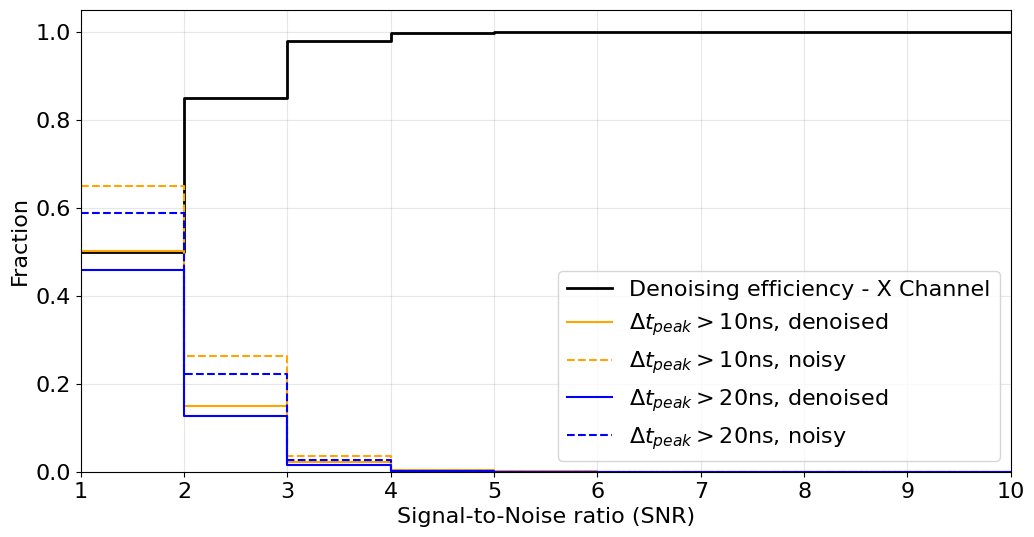

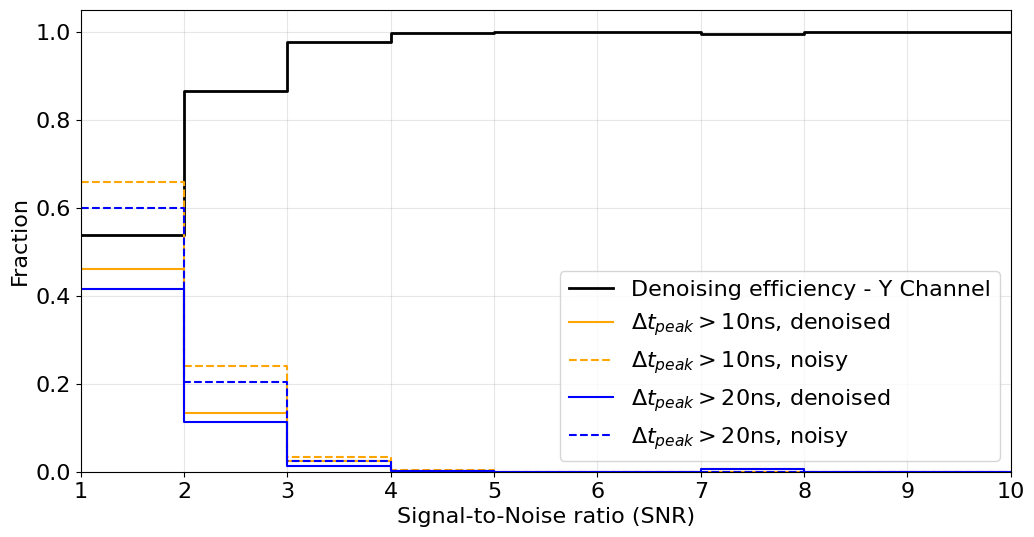

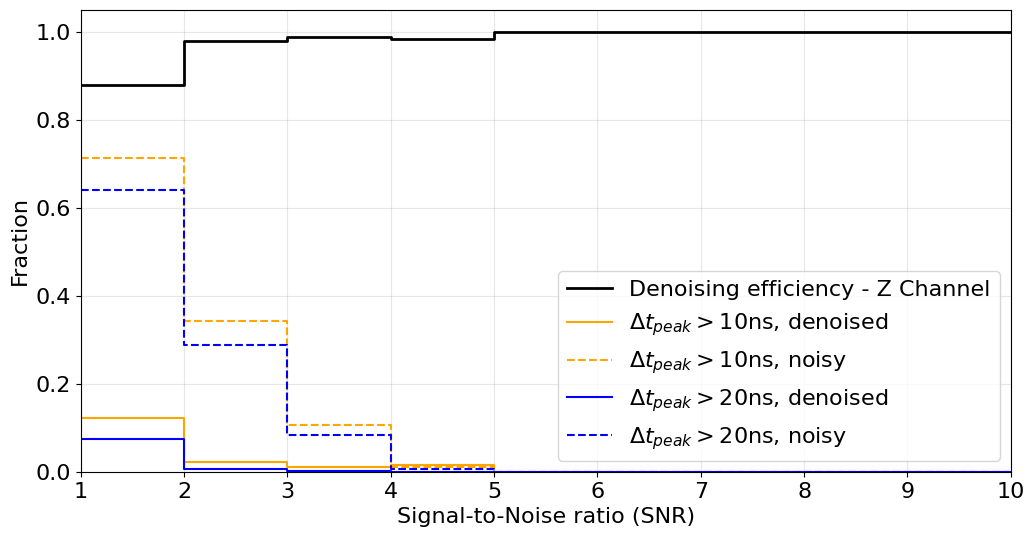

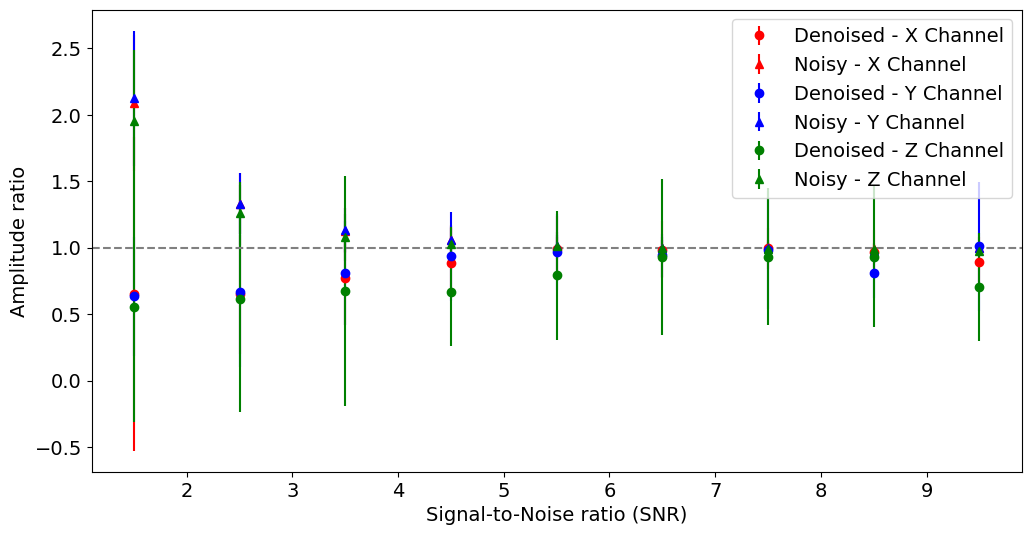

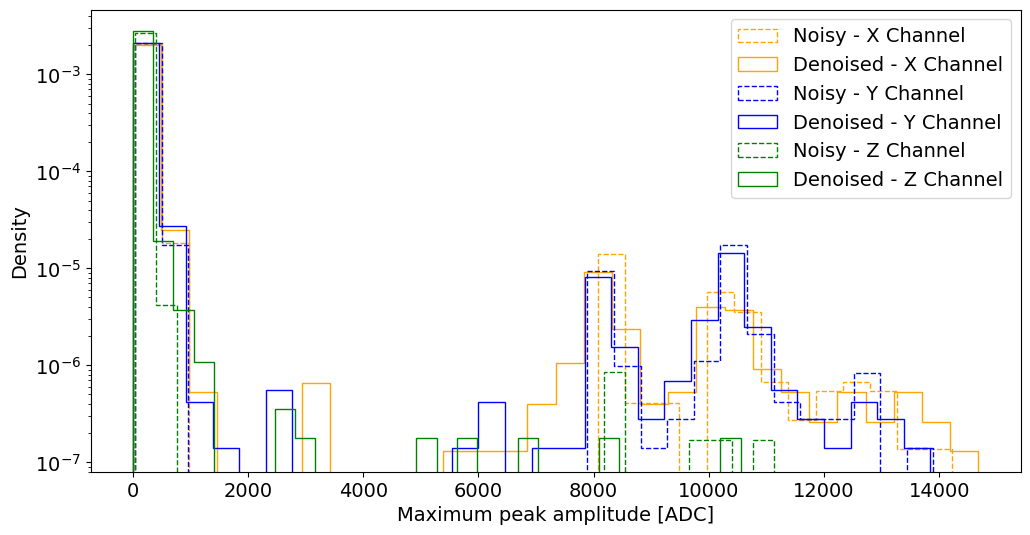

In [16]:
# Path to your ray_results directory
ray_results_path = "/Users/923714256/ray_results/train_validate_wrapper_2025-07-17_01-21-41"

# Look for the best trial directory (trial 00024_24)
best_trial_dir = None
for item in os.listdir(ray_results_path):
    if "train_validate_wrapper_11213_00013_13" in item:
        best_trial_dir = os.path.join(ray_results_path, item)
        break

if best_trial_dir:
    # Read the params.json file
    params_file = os.path.join(best_trial_dir, "params.json")
    if os.path.exists(params_file):
        with open(params_file, 'r') as f:
            config = json.load(f)
        
        print("Model Configuration:")
        print(json.dumps(config['model_config'], indent=2))
save_folder_name = result_v2_path + 'mse_v2_SINGCNN_20_100epochs_v2/results_dev_mse_v2_SINGCNN_20_100epochs_v2_gauss_gal_100_mse_hdf5'
model_path = os.path.join(save_folder_name, 'best_model.pth')
SingleBranchCNN_model_config={
  "decoder_channels": [
    32,
    16,
    8,
    3
  ],
  "time_branch": {
    "conv_channels": 16,
    "res_channels": [
      128,
      256
    ]
  }
}
SingleBranchCNNmodel = SingleBranchCNN(SingleBranchCNN_model_config)
device = torch.device('cpu')
SingleBranchCNNmodel.to(device)
state_dict = torch.load(model_path, map_location=device, weights_only=True)
SingleBranchCNNmodel.load_state_dict(state_dict)
SingleBranchCNNmodel.to(device)
SingleBranchCNNmodel.eval()

traces_plot_v2(testloader = test_loader, 
            model = SingleBranchCNNmodel, 
            num_images = 12, 
            device="cpu",
            save_path = '')

peak_time_analysis(dataloader = test_loader, 
                   model = SingleBranchCNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=1, 
                   max_snr=1e3)

peak_amplitude_analysis_all_channels(dataloader = test_loader, 
                   model = SingleBranchCNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=0, 
                   max_snr=1e3)

### PSNR 

### CNN


Model Configuration:
{
  "decoder_channels": [
    32,
    16,
    8,
    3
  ],
  "freq_branch": {
    "conv_channels": 16,
    "res_channels": [
      16,
      32
    ]
  },
  "time_branch": {
    "conv_channels": 64,
    "res_channels": [
      128,
      256
    ]
  }
}


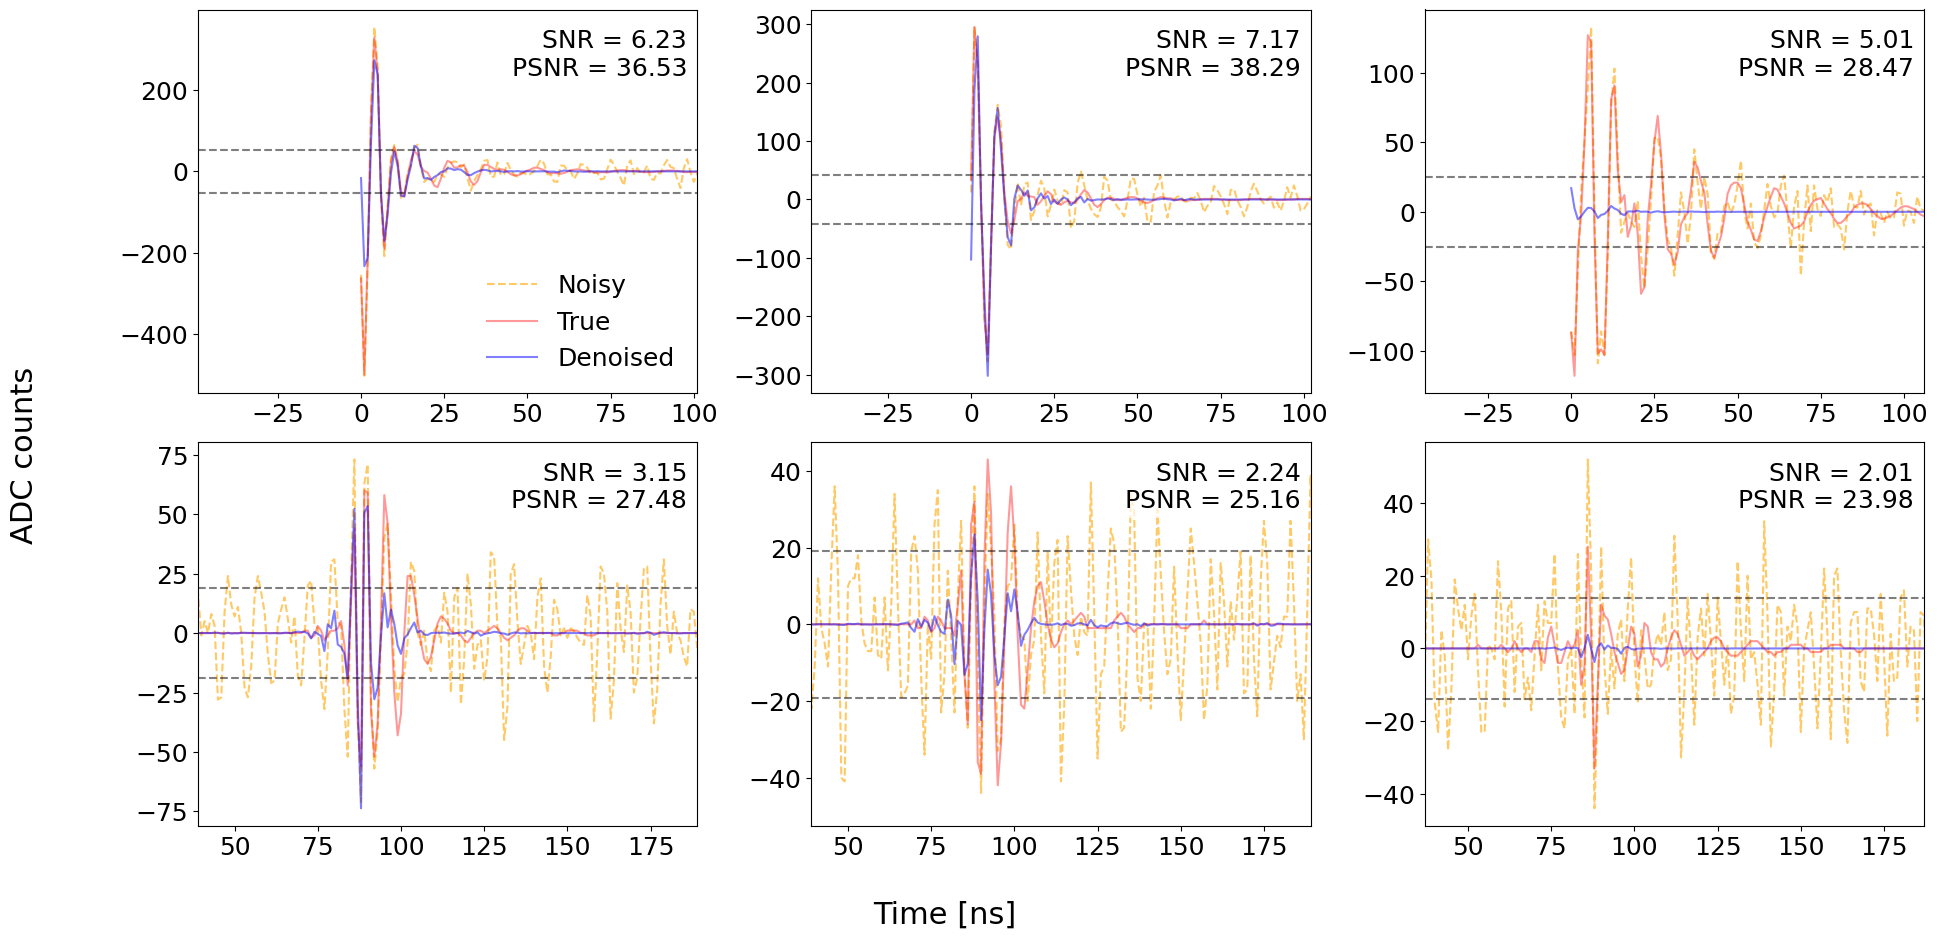

traces_plot_v2 completed


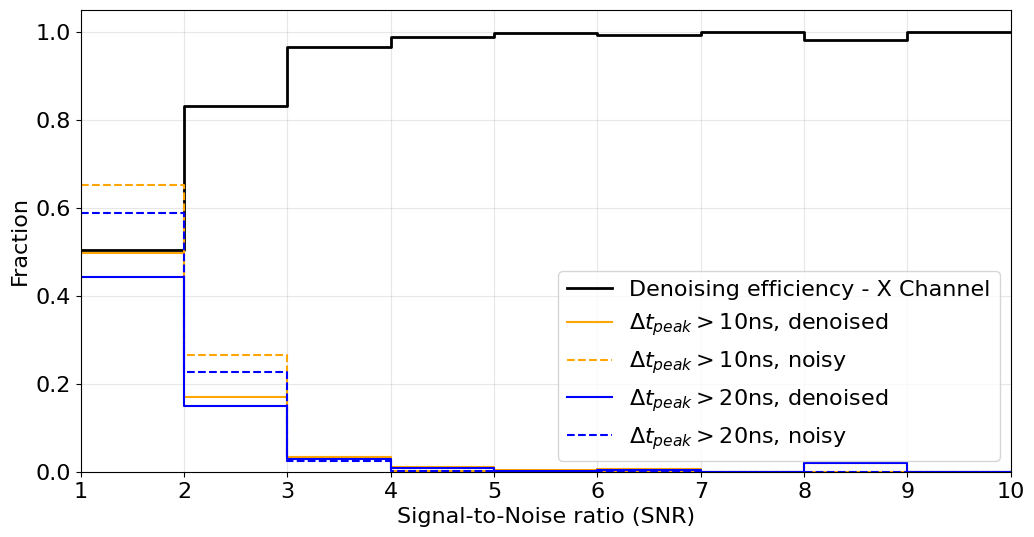

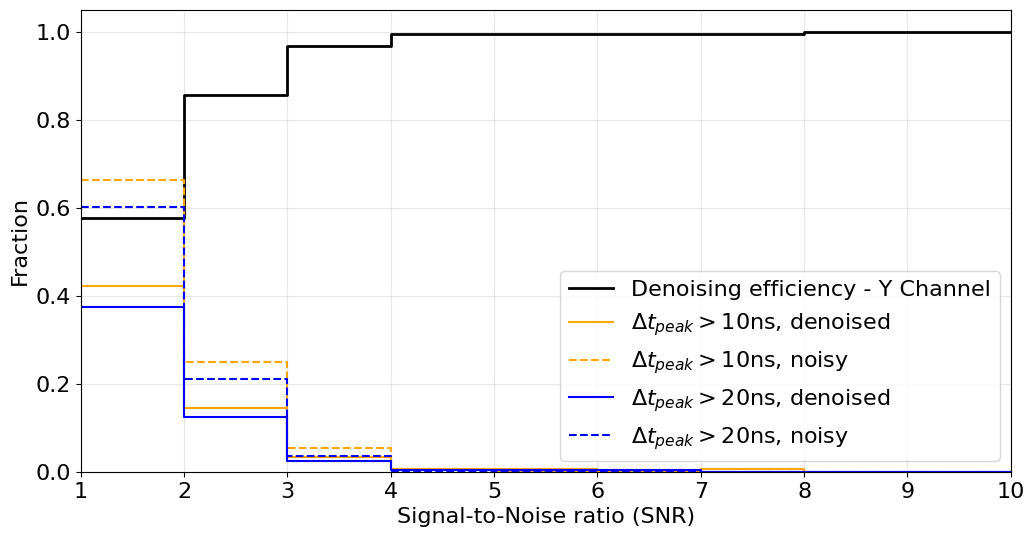

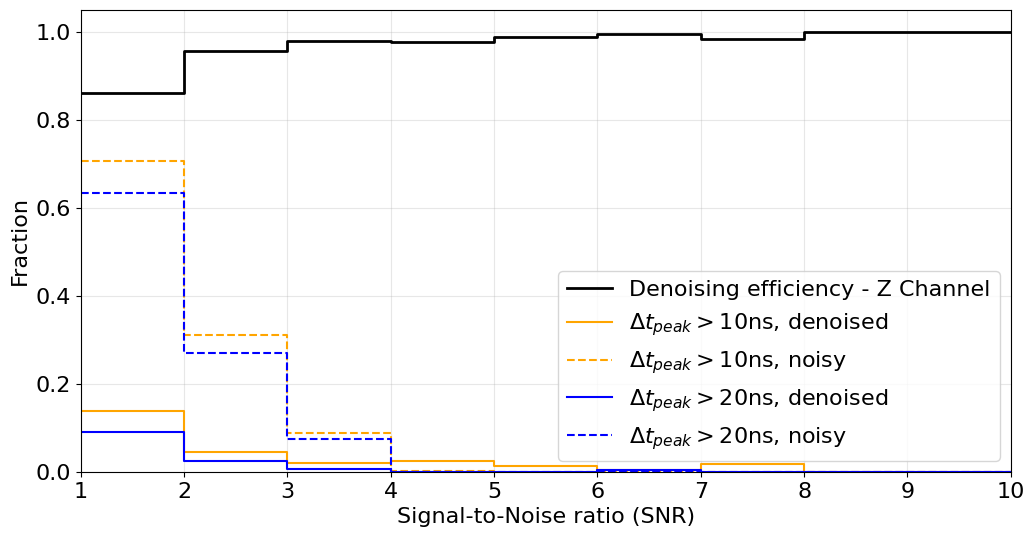

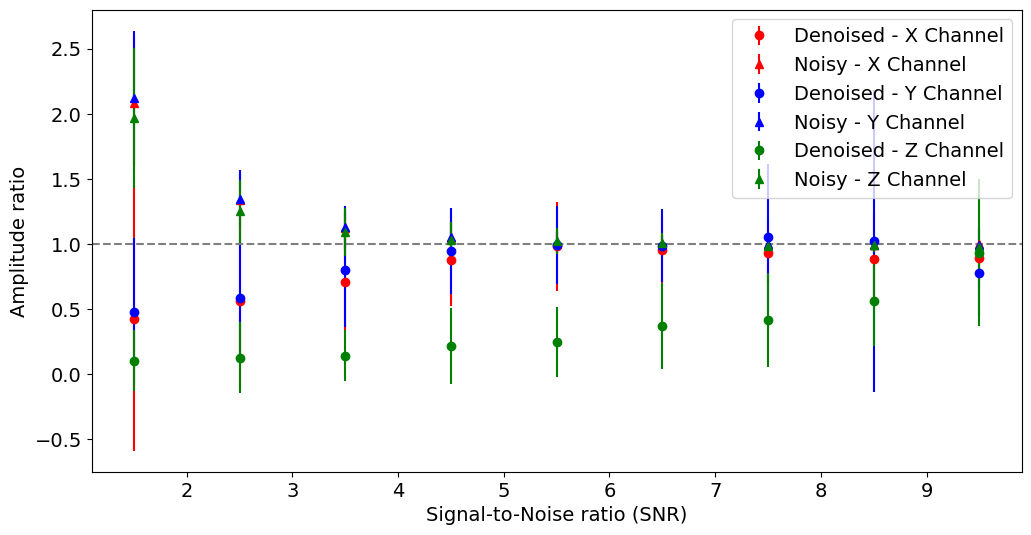

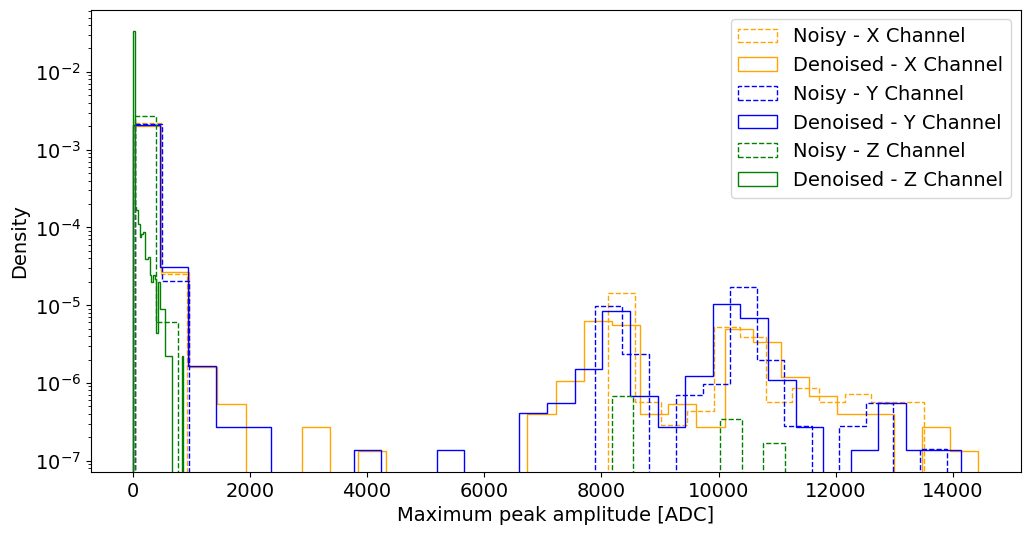

In [17]:
# Path to your ray_results directory
ray_results_path = "/Users/923714256/ray_results/train_validate_wrapper_2025-07-17_14-35-12"

# Look for the best trial directory (trial 00024_24)
best_trial_dir = None
for item in os.listdir(ray_results_path):
    if "train_validate_wrapper_ebdf7_00009_9" in item:
        best_trial_dir = os.path.join(ray_results_path, item)
        break

if best_trial_dir:
    # Read the params.json file
    params_file = os.path.join(best_trial_dir, "params.json")
    if os.path.exists(params_file):
        with open(params_file, 'r') as f:
            config = json.load(f)
        
        print("Model Configuration:")
        print(json.dumps(config['model_config'], indent=2))
save_folder_name = result_v2_path + 'psnr_v2_CNN_20_100epochs_v2/results_dev_psnr_v2_CNN_20_100epochs_v2_gauss_gal_100_psnr_hdf5'
model_path = os.path.join(save_folder_name, 'best_model.pth')

CNN_model_config = {
    'time_branch': {'conv_channels': 64, 'res_channels': (128, 256)},
    'freq_branch': {'conv_channels': 16, 'res_channels': (16, 32)},
    'decoder_channels': [32,16,8,3]
}
CNNmodel = CNNModel(CNN_model_config)
device = torch.device('cpu')
state_dict = torch.load(model_path, map_location=device, weights_only=True)
CNNmodel.load_state_dict(state_dict)
CNNmodel.to(device)
CNNmodel.eval()

traces_plot_v2(testloader = test_loader, 
            model = CNNmodel, 
            num_images = 12, 
            device="cpu",
            save_path = '')


peak_time_analysis(dataloader = test_loader, 
                   model = CNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=1, 
                   max_snr=1e3)


peak_amplitude_analysis_all_channels(dataloader = test_loader, 
                   model = CNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=0, 
                   max_snr=1e3)


### SINGCNN

Model Configuration:
{
  "decoder_channels": [
    128,
    64,
    32,
    3
  ],
  "time_branch": {
    "conv_channels": 32,
    "res_channels": [
      64,
      128
    ]
  }
}


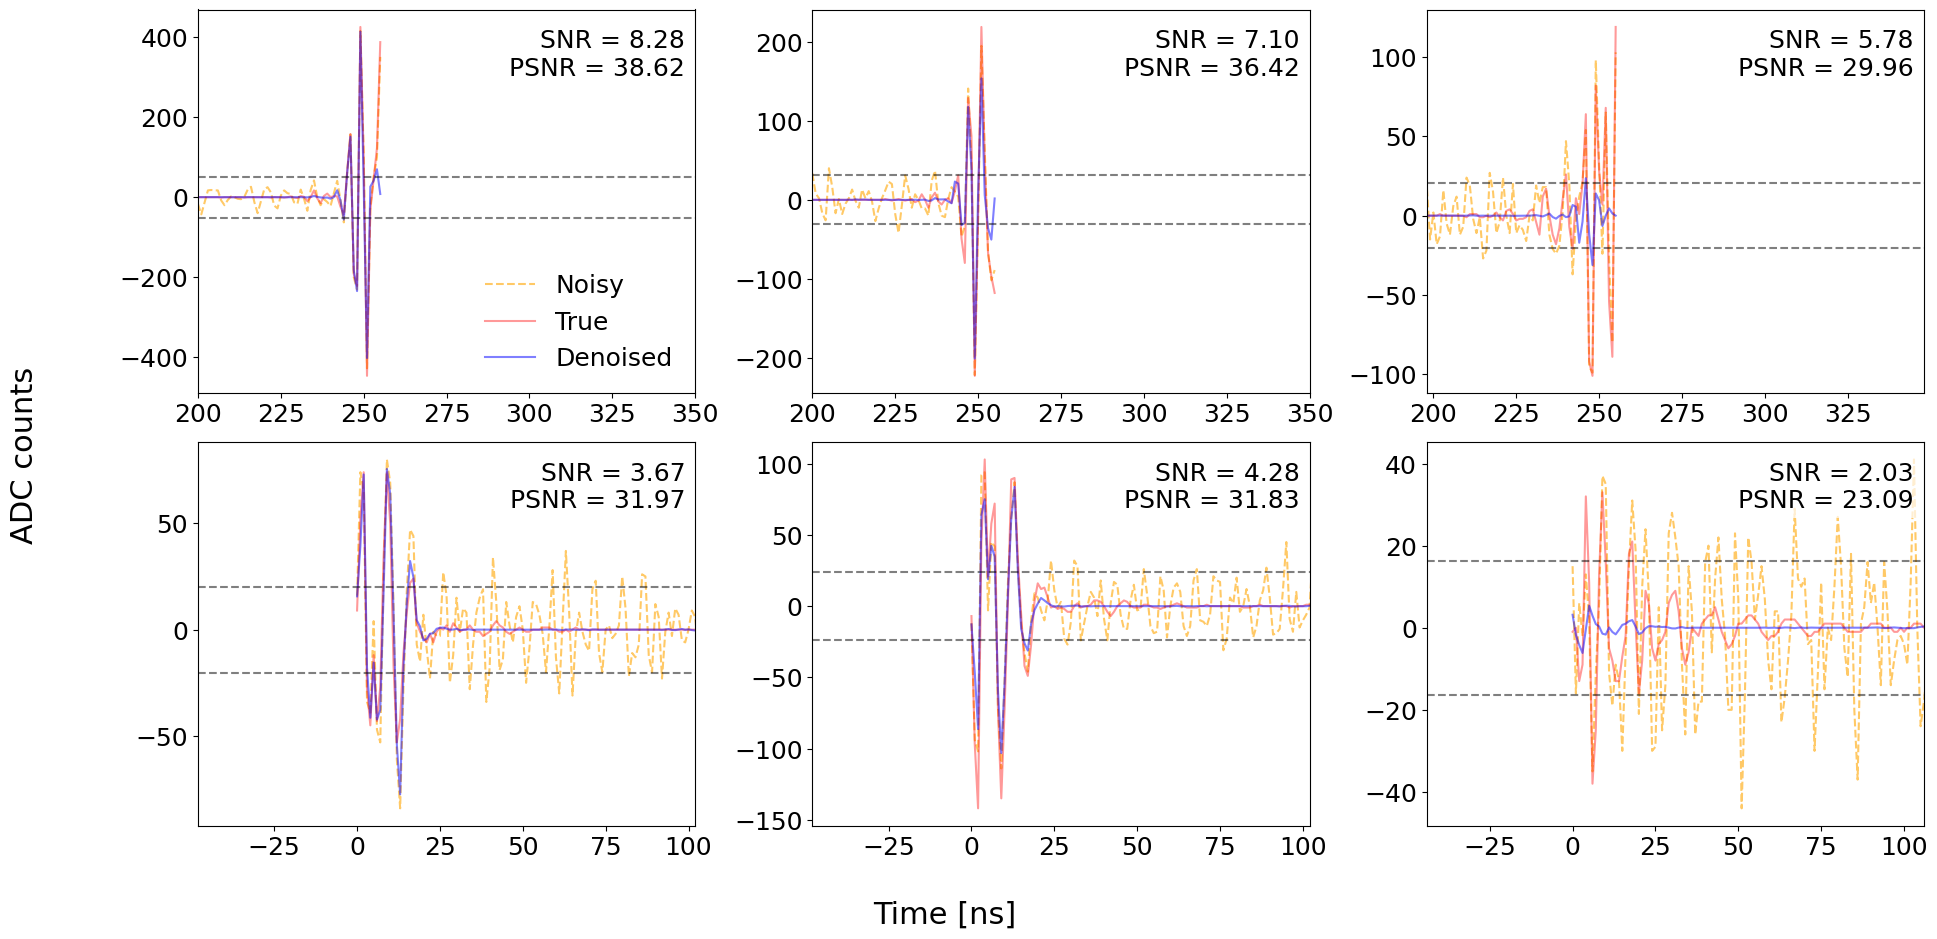

traces_plot_v2 completed


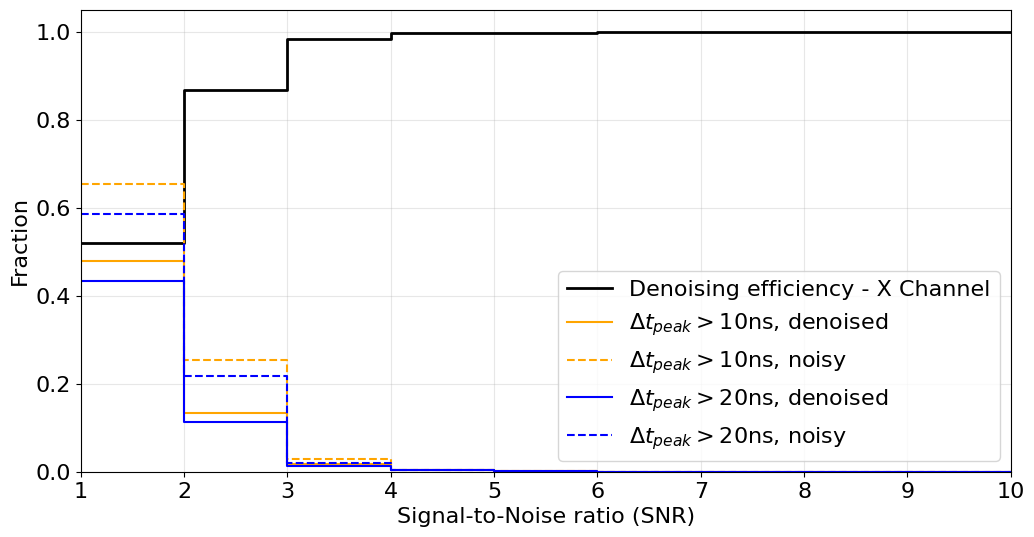

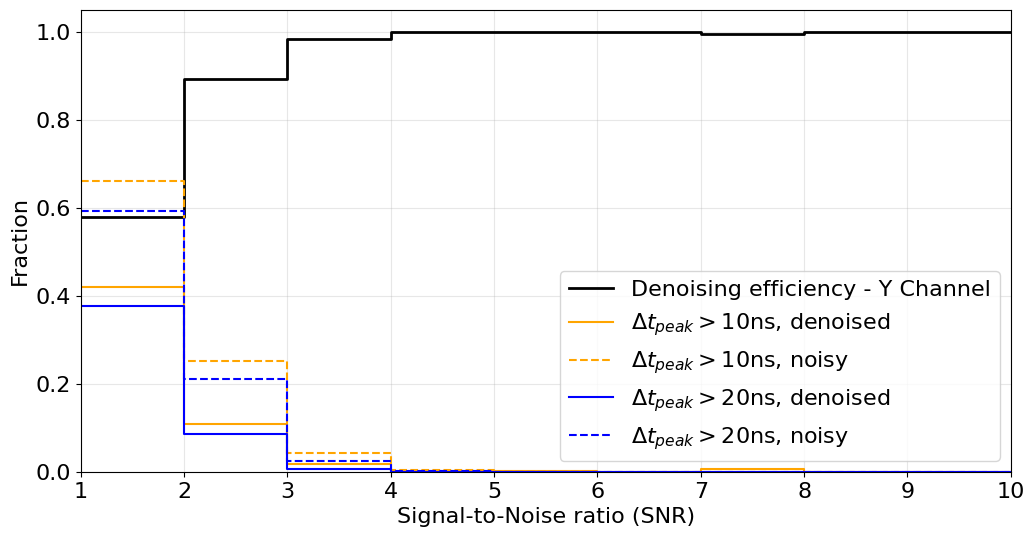

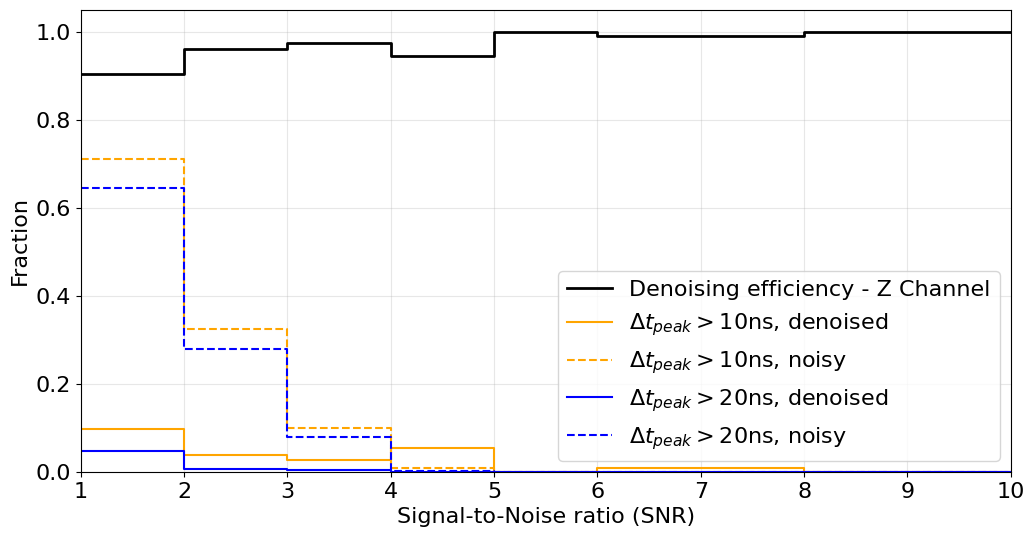

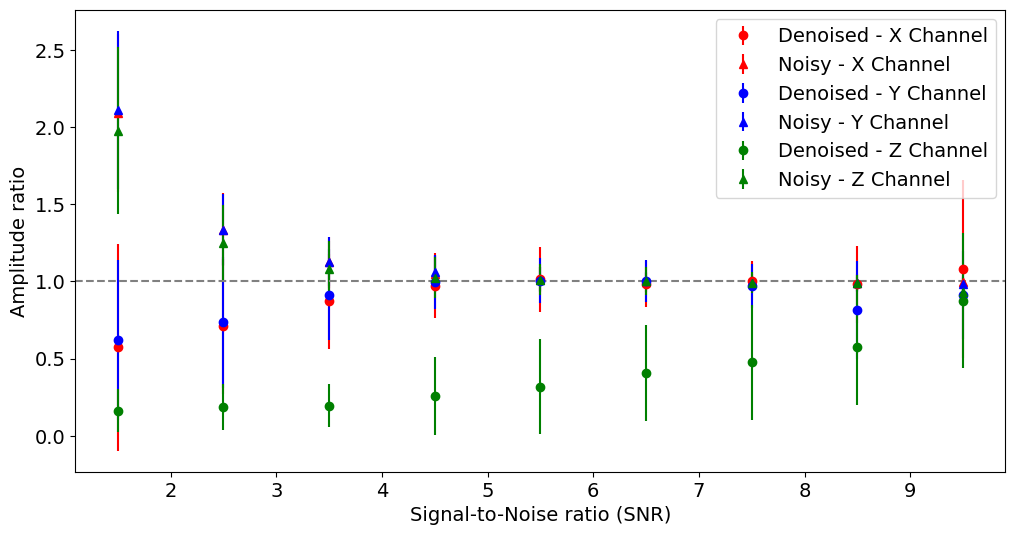

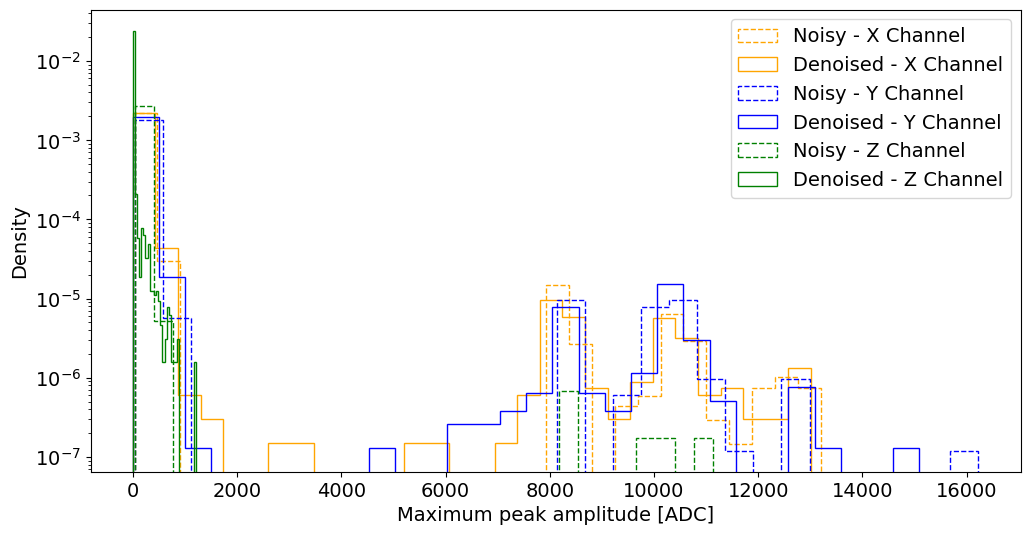

In [18]:
# Path to your ray_results directory
ray_results_path = "/Users/923714256/ray_results/train_validate_wrapper_2025-07-17_14-41-18"

# Look for the best trial directory (trial 00024_24)
best_trial_dir = None
for item in os.listdir(ray_results_path):
    if "train_validate_wrapper_c59d2_00017_17" in item:
        best_trial_dir = os.path.join(ray_results_path, item)
        break

if best_trial_dir:
    # Read the params.json file
    params_file = os.path.join(best_trial_dir, "params.json")
    if os.path.exists(params_file):
        with open(params_file, 'r') as f:
            config = json.load(f)
        
        print("Model Configuration:")
        print(json.dumps(config['model_config'], indent=2))
save_folder_name = result_v2_path + 'psnr_v2_SINGCNN_20_100epochs_v2/results_dev_psnr_v2_SINGCNN_20_100epochs_v2_gauss_gal_100_psnr_hdf5'
model_path = os.path.join(save_folder_name, 'best_model.pth')
SingleBranchCNN_model_config={
  "decoder_channels": [128, 64, 32, 3]  ,
  "time_branch": {
    "conv_channels": 32,
    "res_channels": [
      64,
      128
    ]
  }
}
SingleBranchCNNmodel = SingleBranchCNN(SingleBranchCNN_model_config)
device = torch.device('cpu')
SingleBranchCNNmodel.to(device)
state_dict = torch.load(model_path, map_location=device, weights_only=True)
SingleBranchCNNmodel.load_state_dict(state_dict)
SingleBranchCNNmodel.to(device)
SingleBranchCNNmodel.eval()

traces_plot_v2(testloader = test_loader, 
            model = SingleBranchCNNmodel, 
            num_images = 12, 
            device="cpu",
            save_path = '')

peak_time_analysis(dataloader = test_loader, 
                   model = SingleBranchCNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=1, 
                   max_snr=1e3)

peak_amplitude_analysis_all_channels(dataloader = test_loader, 
                   model = SingleBranchCNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=0, 
                   max_snr=1e3)

### L1

### CNN


Model Configuration:
{
  "decoder_channels": [
    256,
    128,
    64,
    3
  ],
  "freq_branch": {
    "conv_channels": 32,
    "res_channels": [
      128,
      256
    ]
  },
  "time_branch": {
    "conv_channels": 64,
    "res_channels": [
      128,
      256
    ]
  }
}


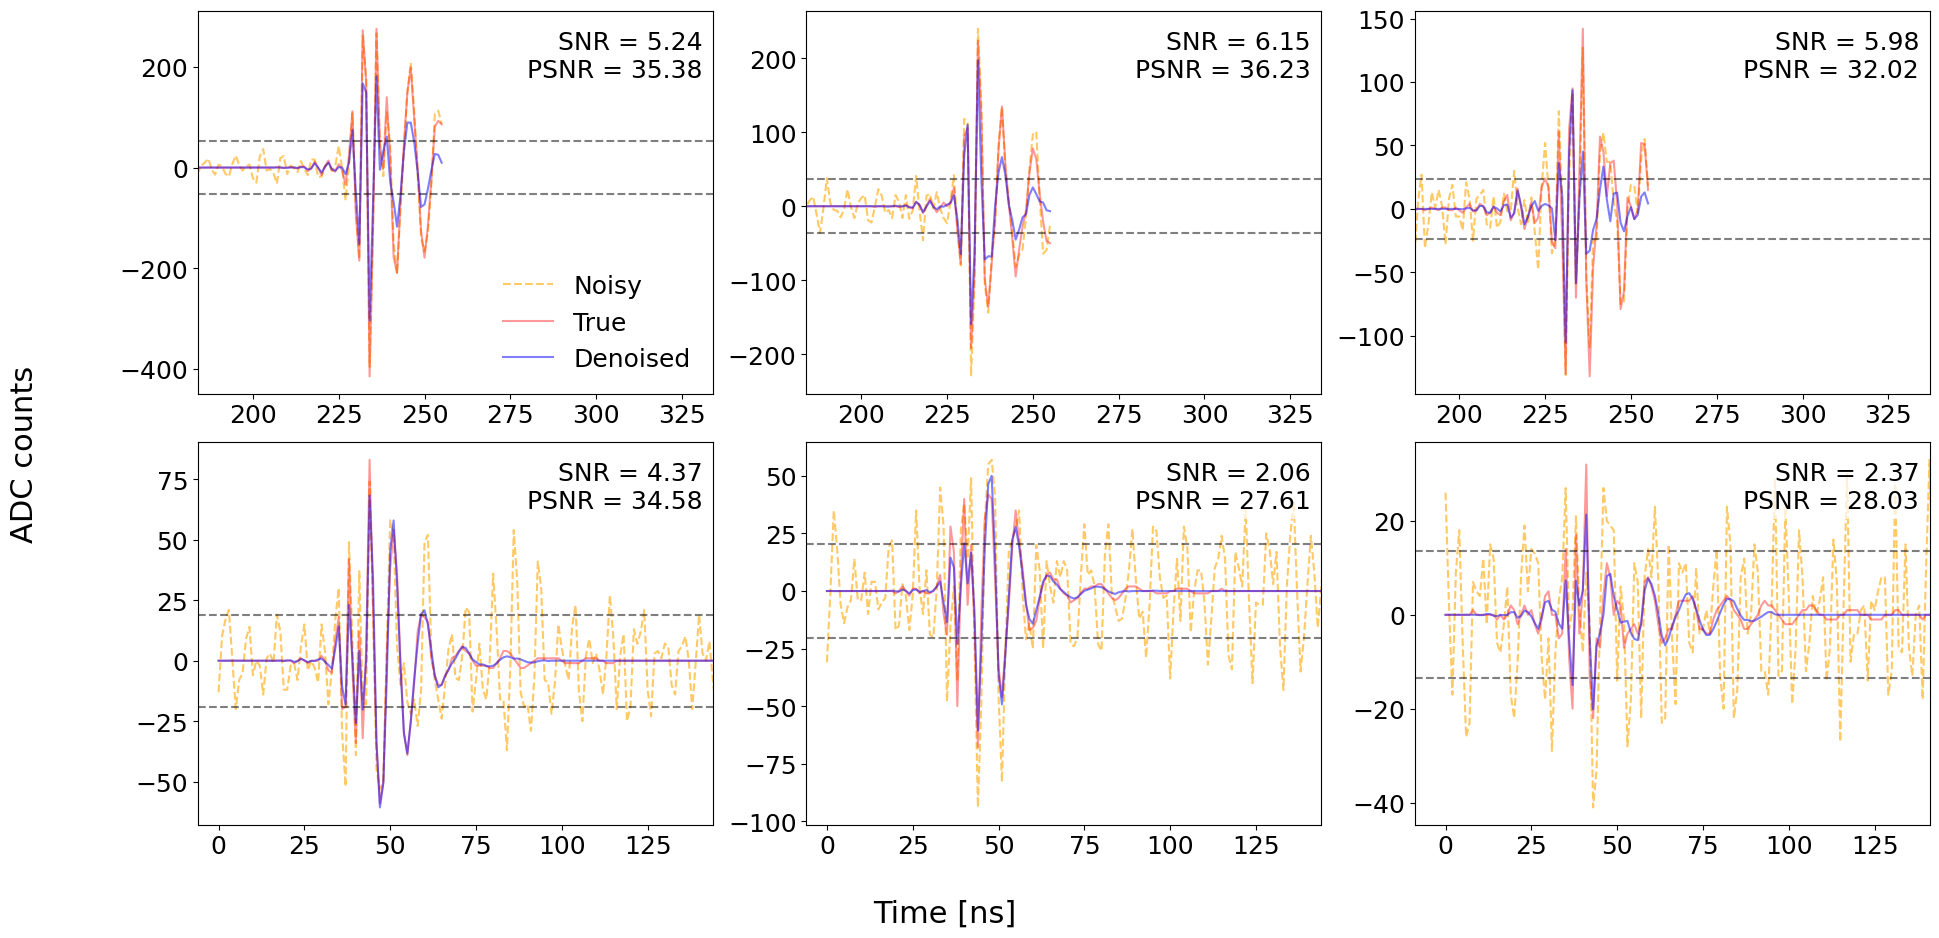

traces_plot_v2 completed


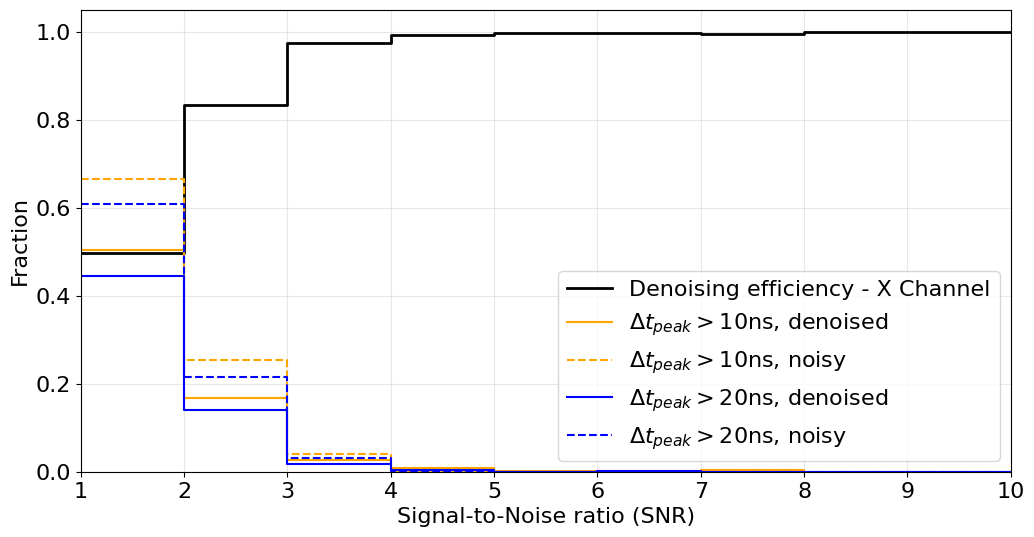

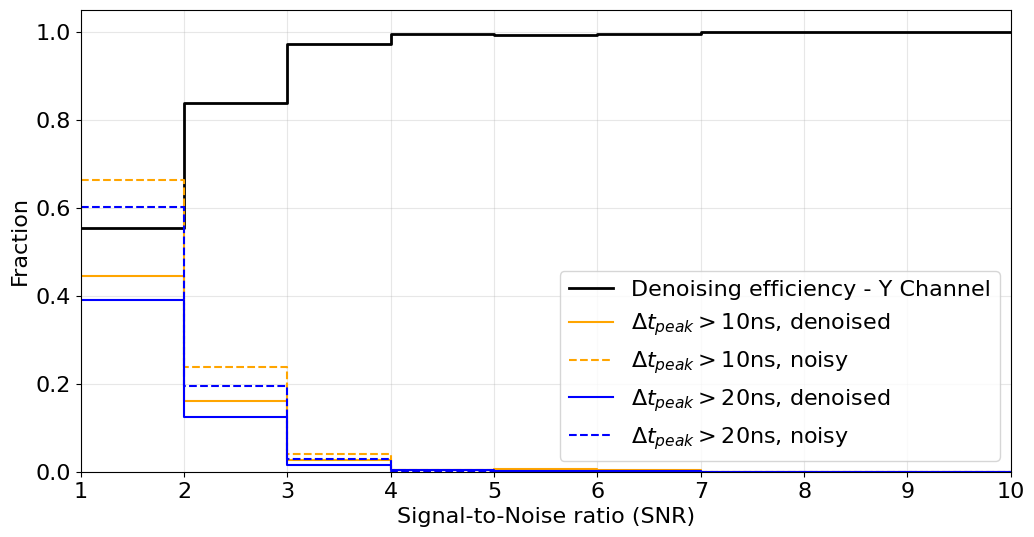

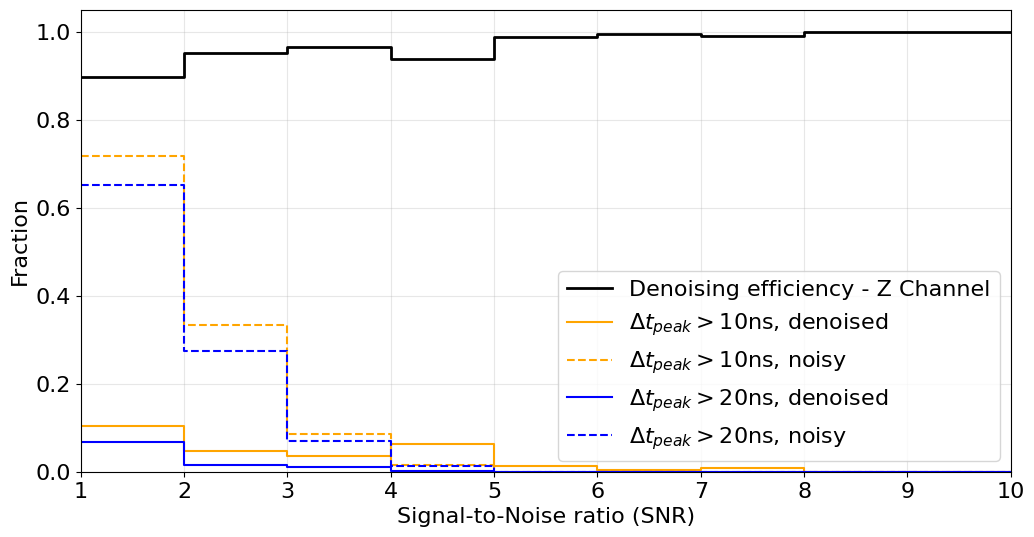

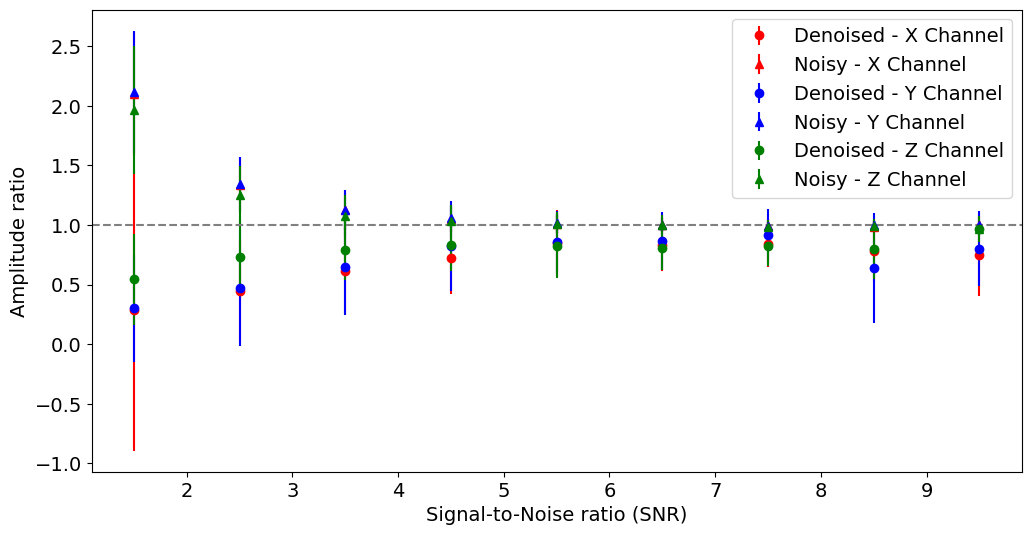

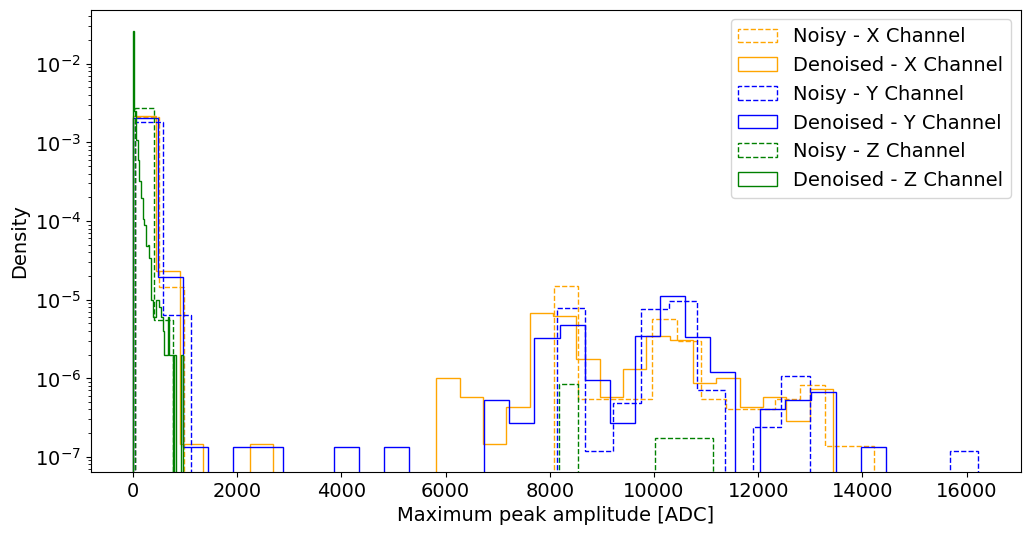

In [19]:
# Path to your ray_results directory
ray_results_path = "/Users/923714256/ray_results/train_validate_wrapper_2025-07-17_23-35-37"

# Look for the best trial directory (trial 00024_24)
best_trial_dir = None
for item in os.listdir(ray_results_path):
    if "train_validate_wrapper_6a41c_00003_3" in item:
        best_trial_dir = os.path.join(ray_results_path, item)
        break

if best_trial_dir:
    # Read the params.json file
    params_file = os.path.join(best_trial_dir, "params.json")
    if os.path.exists(params_file):
        with open(params_file, 'r') as f:
            config = json.load(f)
        
        print("Model Configuration:")
        print(json.dumps(config['model_config'], indent=2))
save_folder_name = result_v2_path + 'l1_v2_CNN_20_100epochs_v2/results_dev_l1_v2_CNN_20_100epochs_v2_gauss_gal_100_l1_hdf5'
model_path = os.path.join(save_folder_name, 'best_model.pth')

CNN_model_config = {
    'time_branch': {'conv_channels': 64, 'res_channels': (128, 256)},
    'freq_branch': {'conv_channels': 32, 'res_channels': (128, 256)},
    'decoder_channels': [256,128,64,3]
}
CNNmodel = CNNModel(CNN_model_config)
device = torch.device('cpu')
state_dict = torch.load(model_path, map_location=device, weights_only=True)
CNNmodel.load_state_dict(state_dict)
CNNmodel.to(device)
CNNmodel.eval()

traces_plot_v2(testloader = test_loader, 
            model = CNNmodel, 
            num_images = 12, 
            device="cpu",
            save_path = '')


peak_time_analysis(dataloader = test_loader, 
                   model = CNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=1, 
                   max_snr=1e3)


peak_amplitude_analysis_all_channels(dataloader = test_loader, 
                   model = CNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=0, 
                   max_snr=1e3)


### SINGCNN


Model Configuration:
{
  "decoder_channels": [
    256,
    128,
    64,
    3
  ],
  "time_branch": {
    "conv_channels": 32,
    "res_channels": [
      128,
      256
    ]
  }
}


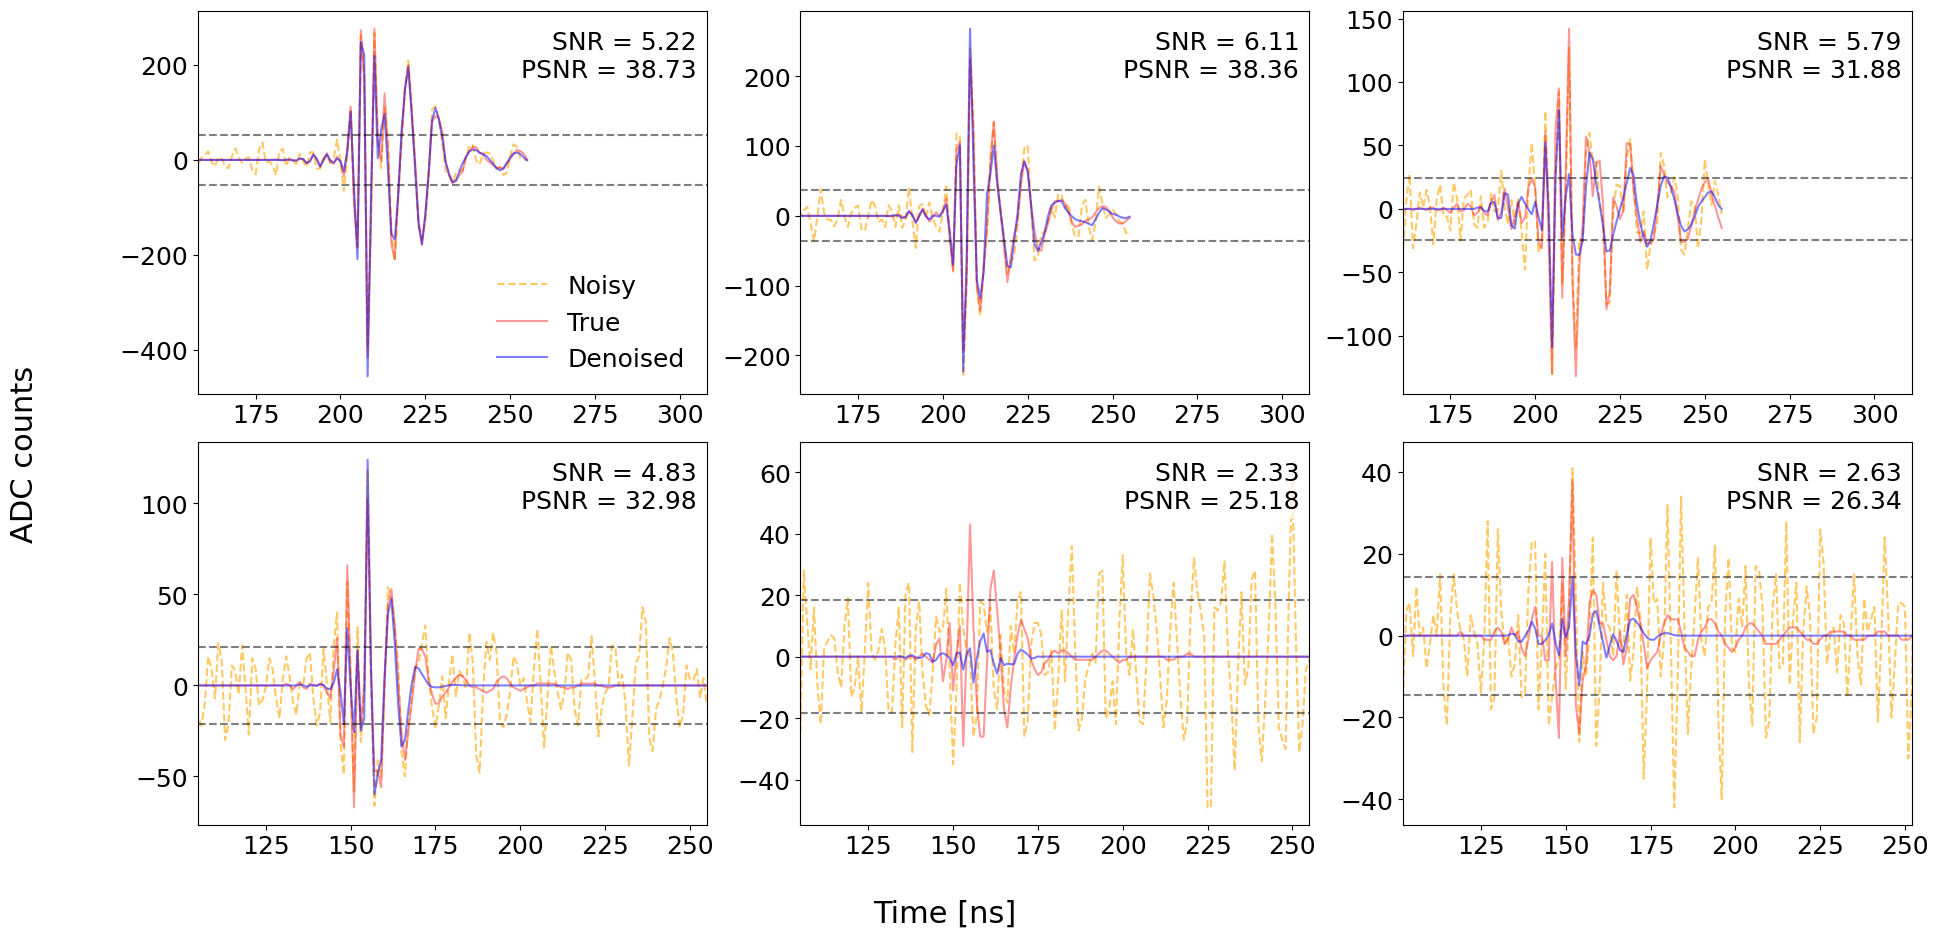

traces_plot_v2 completed


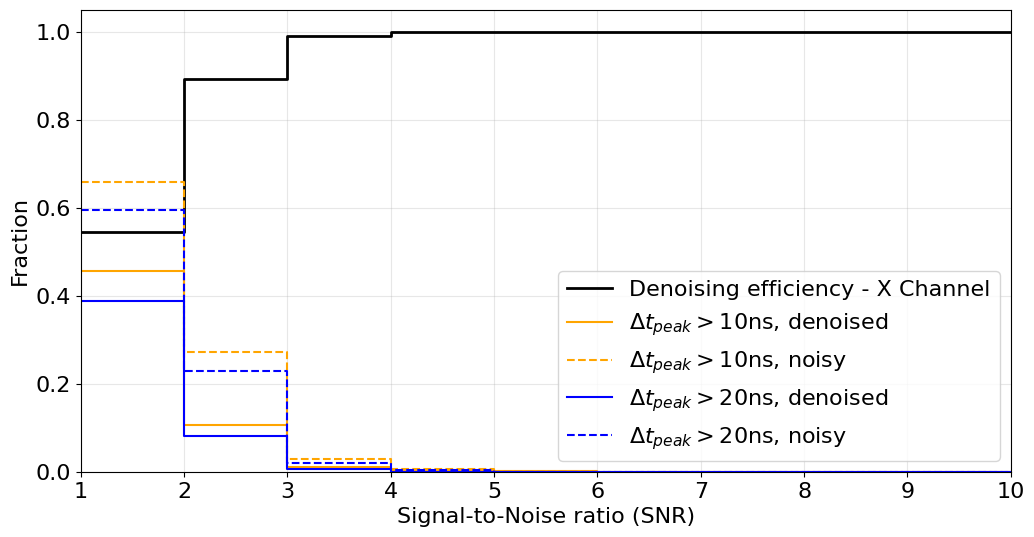

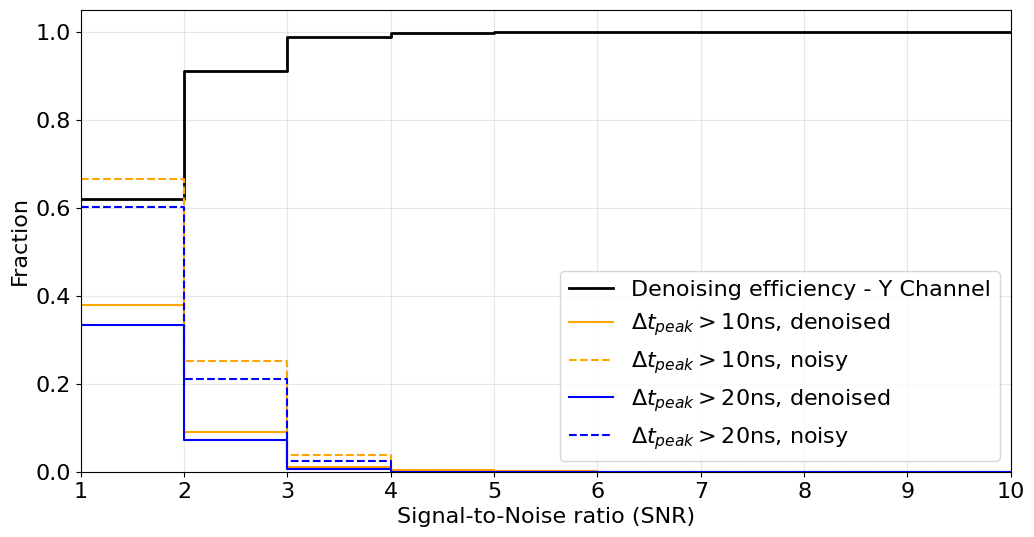

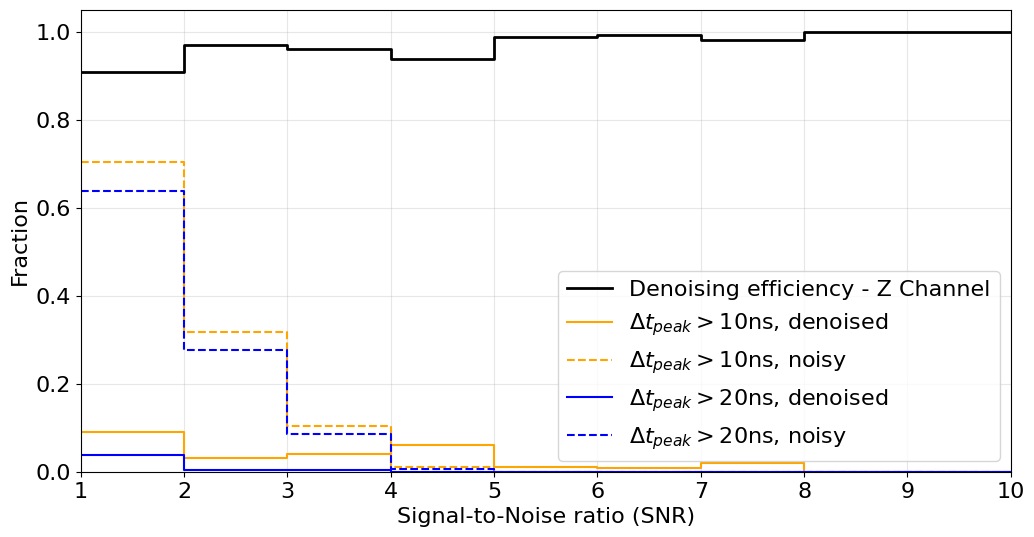

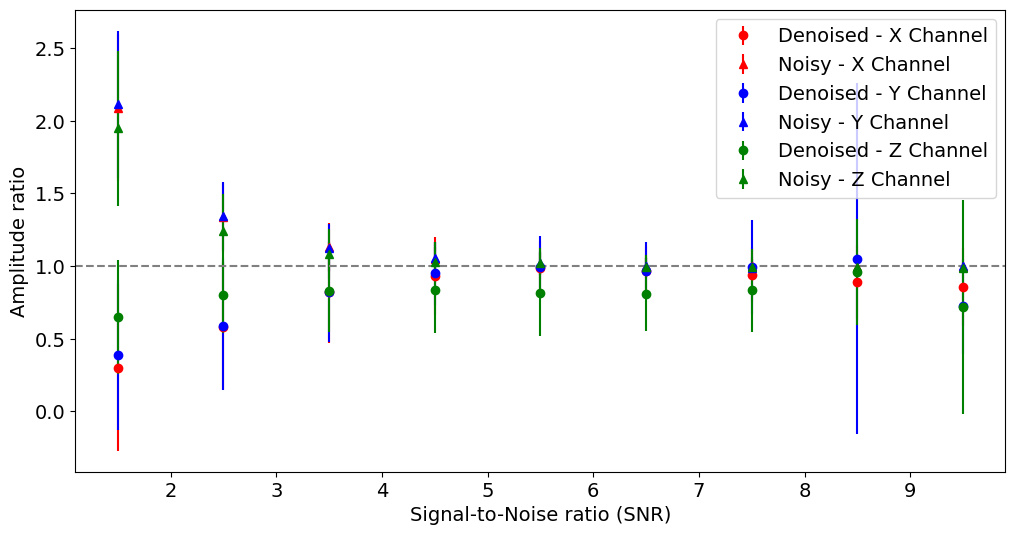

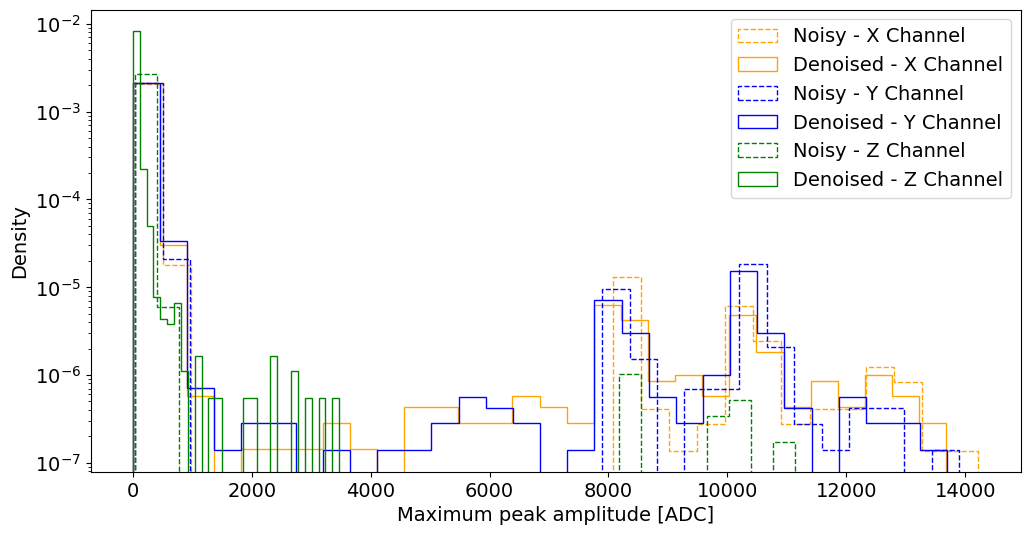

In [20]:
# Path to your ray_results directory
ray_results_path = "/Users/923714256/ray_results/train_validate_wrapper_2025-07-17_23-36-29"

# Look for the best trial directory (trial 00024_24)
best_trial_dir = None
for item in os.listdir(ray_results_path):
    if "train_validate_wrapper_89b0f_00002_2" in item:
        best_trial_dir = os.path.join(ray_results_path, item)
        break

if best_trial_dir:
    # Read the params.json file
    params_file = os.path.join(best_trial_dir, "params.json")
    if os.path.exists(params_file):
        with open(params_file, 'r') as f:
            config = json.load(f)
        
        print("Model Configuration:")
        print(json.dumps(config['model_config'], indent=2))
save_folder_name = result_v2_path + 'l1_v2_SINGCNN_20_100epochs_v2/results_dev_l1_v2_SINGCNN_20_100epochs_v2_gauss_gal_100_l1_hdf5'
model_path = os.path.join(save_folder_name, 'best_model.pth')
SingleBranchCNN_model_config={
  "decoder_channels": [256, 128, 64, 3]  ,
  "time_branch": {
    "conv_channels": 32,
    "res_channels": [
      128,
      256
    ]
  }
}
SingleBranchCNNmodel = SingleBranchCNN(SingleBranchCNN_model_config)
device = torch.device('cpu')
SingleBranchCNNmodel.to(device)
state_dict = torch.load(model_path, map_location=device, weights_only=True)
SingleBranchCNNmodel.load_state_dict(state_dict)
SingleBranchCNNmodel.to(device)
SingleBranchCNNmodel.eval()

traces_plot_v2(testloader = test_loader, 
            model = SingleBranchCNNmodel, 
            num_images = 12, 
            device="cpu",
            save_path = '')

peak_time_analysis(dataloader = test_loader, 
                   model = SingleBranchCNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=1, 
                   max_snr=1e3)

peak_amplitude_analysis_all_channels(dataloader = test_loader, 
                   model = SingleBranchCNNmodel ,
                   model_path=model_path, 
                   device='cpu', 
                   min_snr=0, 
                   max_snr=1e3)